Import libraries

In [ ]:
import pandas as pd
import numpy as np
import sklearn
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional, Union, Literal

Import Data

In [770]:
# Define base directory
BASE_DIR = os.getcwd()

In [771]:
# Define file location
path_loans = os.path.join(BASE_DIR, "Data", "loan_data_2007_2014.csv")
loans_df_backup = pd.read_csv(path_loans)

C:\Users\jluyandosanchez\AppData\Local\Temp\ipykernel_23980\1703822281.py:3: DtypeWarning: Columns (0: desc) have mixed types. Specify dtype option on import or set low_memory=False.
  loans_df_backup = pd.read_csv(path_loans)


Explore Data

In [772]:
# Make a copy of the data for editing
loans_data = loans_df_backup.copy()
# to make jupyter display all the columns
pd.options.display.max_columns = None
# Clear column Unnamed: 0	
loans_data = loans_data.drop(columns=["Unnamed: 0"], errors="ignore") # ignore this if the column was already cleared out
# Display the df
loans_data.head(3)
#loans_data.tail(3)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.0,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.0,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.0,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [773]:
# Get all the column names
loans_data.columns.values

<StringArray>
[                         'id',                   'member_id',
                   'loan_amnt',                 'funded_amnt',
             'funded_amnt_inv',                        'term',
                    'int_rate',                 'installment',
                       'grade',                   'sub_grade',
                   'emp_title',                  'emp_length',
              'home_ownership',                  'annual_inc',
         'verification_status',                     'issue_d',
                 'loan_status',                  'pymnt_plan',
                         'url',                        'desc',
                     'purpose',                       'title',
                    'zip_code',                  'addr_state',
                         'dti',                 'delinq_2yrs',
            'earliest_cr_line',              'inq_last_6mths',
      'mths_since_last_delinq',      'mths_since_last_record',
                    'open_acc',          

In [774]:
# Info method to get the data types
loans_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 74 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           466285 non-null  int64  
 1   member_id                    466285 non-null  int64  
 2   loan_amnt                    466285 non-null  int64  
 3   funded_amnt                  466285 non-null  int64  
 4   funded_amnt_inv              466285 non-null  float64
 5   term                         466285 non-null  str    
 6   int_rate                     466285 non-null  float64
 7   installment                  466285 non-null  float64
 8   grade                        466285 non-null  str    
 9   sub_grade                    466285 non-null  str    
 10  emp_title                    438697 non-null  str    
 11  emp_length                   445277 non-null  str    
 12  home_ownership               466285 non-null  str    
 13  annual_inc

Transform variables to the type the actually need to be

In [775]:
# EMPLOYEMENT LENGTH --> Strings to Numeric

# Let's transform our data into integer values
loans_data.emp_length.unique() # get rid off value years/year and other signs
# Get a new integer column out of it
loans_data["emp_length_int"] = (
    loans_data["emp_length"]
        .replace({"< 1 year": "0", "n/a": "0"}) # Replace all of these 
        .str.extract(r"(\d+)", expand=False)
        .fillna(0) # fill nas with zeros
        .astype(int)
)

type(loans_data["emp_length_int"][0]) # now it is integer

numpy.int64

In [776]:
# EARLIEST CREDIT LINE --> Strings to Dates

loans_data.earliest_cr_line.unique()

# Turn an input string in a time stamp, requiring that we specify the format of how the string represents time
loans_data['earliest_cr_line_date'] = pd.to_datetime(loans_data['earliest_cr_line'], format= '%b-%y')

print(loans_data["earliest_cr_line_date"][0]) # now it is a date/timestamp

# Let's get the difference between a refernece date and how much time has passed since then
# We get as result the number of days that have passes since the start of the earliest credit line comapred to our setup start date
defined_reference_date = pd.to_datetime('2017-12-01')
loans_data['days_since_earliest_cr_line'] = defined_reference_date - loans_data.earliest_cr_line_date

# And to get the months
loans_data['mths_since_earliest_cr_line'] = (
    loans_data['days_since_earliest_cr_line'].dt.days / 30.44
).round()

# Get descriptive statistics
loans_data['mths_since_earliest_cr_line'].describe()

1985-01-01 00:00:00


count    466256.000000
mean        239.482430
std          93.974829
min        -612.000000
25%         183.000000
50%         225.000000
75%         285.000000
max         587.000000
Name: mths_since_earliest_cr_line, dtype: float64

In [777]:
# We get some negative difference which should not be the case unless our refrence date is in the past
loans_data.loc[:, ['earliest_cr_line', 'earliest_cr_line_date', 'mths_since_earliest_cr_line']][loans_data.mths_since_earliest_cr_line < 0]

,earliest_cr_line,earliest_cr_line_date,mths_since_earliest_cr_line
1580,Sep-62,2062-09-01,-537.0
1770,Sep-68,2068-09-01,-609.0
2799,Sep-64,2064-09-01,-561.0
3282,Sep-67,2067-09-01,-597.0
3359,Feb-65,2065-02-01,-566.0
...,...,...,...
464003,Jan-68,2068-01-01,-601.0
464260,Jul-66,2066-07-01,-583.0
465100,Oct-67,2067-10-01,-598.0
465500,Sep-67,2067-09-01,-597.0


In [778]:
# Probably a mistake because this values are from the 1960s and not 2060s
# Let's assign all of these negative the maximum 'mths_since_earliest_cr_line' value
max_mths_cr_loans_data = loans_data["mths_since_earliest_cr_line"].max()

# Replace all the negative valeus with the maximum
loans_data.loc[
    loans_data["mths_since_earliest_cr_line"] < 0, # Filter
    "mths_since_earliest_cr_line" # Column to take new values as per the filter
] = max_mths_cr_loans_data

print(loans_data["mths_since_earliest_cr_line"].min())

73.0


In [779]:
# TERM --> String to Numeric
print(loans_data.term.head(3))

# Only two values
loans_data.term.unique()

# Get rid off 'months' from "36 months" or "60 months"
loans_data["term_int"] = (
    loans_data["term"]
        .str.replace(" months", "", regex=False) # Replace " months" with ""
        .fillna(0) # fill nas with zeros
        .astype(int)
)

print(loans_data.term_int.head(3))


0     36 months
1     60 months
2     36 months
Name: term, dtype: str


0    36
1    60
2    36
Name: term_int, dtype: int64


In [780]:
# ISSUE DATE --> Strings to Dates

loans_data.issue_d.unique()
print(loans_data.issue_d.head(3))

# Turn an input string in a time stamp, requiring that we specify the format of how the string represents time
loans_data['issue_d_date'] = pd.to_datetime(loans_data['issue_d'], format= '%b-%y')

print(loans_data["issue_d_date"][0]) # now it is a date/timestamp

# Let's get the difference between a refernece date and how much time has passed since then
# We get as result the number of days that have passes since the start of the earliest credit line comapred to our setup start date
defined_reference_date = pd.to_datetime('2017-12-01')
loans_data['days_since_issue_d'] = defined_reference_date - loans_data.issue_d_date

# And to get the months
loans_data['mths_since_issue_d'] = (
    loans_data['days_since_issue_d'].dt.days / 30.44
).round()

# Get the head
print(loans_data.mths_since_issue_d.head(3))

# Get descriptive statistics
print(loans_data['mths_since_issue_d'].describe()) # Make sense

0    Dec-11
1    Dec-11
2    Dec-11
Name: issue_d, dtype: str
2011-12-01 00:00:00
0    72.0
1    72.0
2    72.0
Name: mths_since_issue_d, dtype: float64
count    466285.000000
mean         51.255187
std          14.340154
min          36.000000
25%          41.000000
50%          47.000000
75%          57.000000
max         126.000000
Name: mths_since_issue_d, dtype: float64


Preprocessing discrete variables:
- grade
- sub_grade
- home_ownership
- verification_status
- loan_status
- purpose
- addr_state
- initial_list_status

Create dummy variables

Explanation of this transformation:

Categorical variables must be converted into dummy variables because regression models can only work with numerical inputs. Dummies represent each category as a separate 0/1 variable, allowing the model to learn the impact of each category without assuming any artificial order or distance between them.

In [781]:
# Categorical columns to be converted into dummies
categorical_cols = [
    "grade",
    "sub_grade",
    "home_ownership",
    "verification_status",
    "loan_status",
    "purpose",
    "addr_state",
    "initial_list_status"
]

# Process of creating dummies for all of the categorical columns
loan_data_dummies = pd.get_dummies(
    loans_data[categorical_cols],
    prefix=categorical_cols,
    prefix_sep=":",
    dtype=int
)

# Make it a data frame
loan_data_dummies.head(3)
type(loan_data_dummies)

# Add these dmummy variables as extra columns
loans_data_w_dummies = pd.concat([loans_data, loan_data_dummies], axis=1) # axis=1: concatenation by columns, axis=0: concatenation by rows
loans_data_w_dummies.columns.values

<StringArray>
[                   'id',             'member_id',             'loan_amnt',
           'funded_amnt',       'funded_amnt_inv',                  'term',
              'int_rate',           'installment',                 'grade',
             'sub_grade',
 ...
         'addr_state:TX',         'addr_state:UT',         'addr_state:VA',
         'addr_state:VT',         'addr_state:WA',         'addr_state:WI',
         'addr_state:WV',         'addr_state:WY', 'initial_list_status:f',
 'initial_list_status:w']
Length: 208, dtype: str

Check for missing values and clean

Variables we will need for the analysis:
- annual_inc
- delinq_2yrs
- inq_last_6mths
- open_acc
- pub_rec
- total_acc
- acc_now_delinq
- total_rev_hi_lim
- emp_length_int
- mths_since_earliest_cr_line

In [782]:
# Check if there are any null values
cols = [
    "annual_inc",
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "total_acc",
    "acc_now_delinq",
    "total_rev_hi_lim",
    "emp_length_int",
    "mths_since_earliest_cr_line"
]

# Get the summary of the null values
def get_null_summary(df, cols):
    return pd.DataFrame({
        "null_count": loans_data_w_dummies[cols].isna().sum(), # number of empty rows
        "null_pct": (loans_data_w_dummies[cols].isna().mean() * 100).round(2), # percentage of the total
        "var_type": loans_data_w_dummies[cols].dtypes.astype(str),
        "mean": loans_data_w_dummies[cols].mean()
    }).sort_values("null_count", ascending=False)


null_summary1 = get_null_summary(loans_data_w_dummies, cols)
print(null_summary1)

                             null_count  null_pct var_type          mean
total_rev_hi_lim                  70276     15.07  float64  30379.087771
delinq_2yrs                          29      0.01  float64      0.284678
total_acc                            29      0.01  float64     25.064430
inq_last_6mths                       29      0.01  float64      0.804745
pub_rec                              29      0.01  float64      0.160564
open_acc                             29      0.01  float64     11.187069
mths_since_earliest_cr_line          29      0.01  float64    242.385374
acc_now_delinq                       29      0.01  float64      0.004002
annual_inc                            4      0.00  float64  73277.381470
emp_length_int                        0      0.00    int64      5.723307


In [783]:
# # OPTION 1: Do a replacement using the mean value
# # Let's do a replacement of the null values with the average
# # Replace all null values with the respective column mean
# loans_data_w_dummies[cols] = loans_data_w_dummies[cols].astype(float)

# # use fillna
# loans_data_w_dummies[cols] = loans_data_w_dummies[cols].fillna(
#     loans_data_w_dummies[cols].mean()
# )


# OPTION 2: Do a per variable accurate replacement

# ========== total_rev_hi_lim ================
# if there is no data for the revolving limit, we assume it is equal to the fundded amount
loans_data_w_dummies["total_rev_hi_lim"] = (
    loans_data_w_dummies["total_rev_hi_lim"]
    .fillna(loans_data_w_dummies["funded_amnt"])
)

# ========== annual_inc ================
# Use the mean to fill missing values
loans_data_w_dummies["annual_inc"] = loans_data_w_dummies["annual_inc"].fillna(
    loans_data_w_dummies["annual_inc"].mean()
)

# ========== ALL OTHERS ================
# Fill with zero
cols_zero = [
    "delinq_2yrs",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "total_acc",
    "acc_now_delinq",
    "emp_length_int",
    "mths_since_earliest_cr_line"
]

# Fill with zeros
loans_data_w_dummies[cols_zero] = loans_data_w_dummies[cols_zero].fillna(
    0
)

# Get the summary of the null values
null_summary2 = get_null_summary(loans_data_w_dummies, cols)
print(null_summary2)

                             null_count  null_pct var_type          mean
annual_inc                            0       0.0  float64  73277.381470
delinq_2yrs                           0       0.0  float64      0.284661
inq_last_6mths                        0       0.0  float64      0.804695
open_acc                              0       0.0  float64     11.186373
pub_rec                               0       0.0  float64      0.160554
total_acc                             0       0.0  float64     25.062871
acc_now_delinq                        0       0.0  float64      0.004002
total_rev_hi_lim                      0       0.0  float64  27573.671883
emp_length_int                        0       0.0    int64      5.723307
mths_since_earliest_cr_line           0       0.0  float64    242.370299


# PD MODEL

Data Preparation

Dependent variable. Good(Non-defaulted)/Bad(defaulted) definition. Default and Non-default accounts.

In [784]:
loans_data_w_dummies.loan_status.unique()
# Fully Paid',  ===> GOOD
#                                          'Charged Off',  ===> BAD
#                                              'Current',  ===> GOOD
#                                              'Default',  ===> BAD
#                                   'Late (31-120 days)',  ===> BAD
#                                      'In Grace Period',  ===> GOOD
#                                    'Late (16-30 days)',  ===> GOOD
#   'Does not meet the credit policy. Status:Fully Paid',  ===> GOOD
#  'Does not meet the credit policy. Status:Charged Off']  ===> BAD

<StringArray>
[                                         'Fully Paid',
                                         'Charged Off',
                                             'Current',
                                             'Default',
                                  'Late (31-120 days)',
                                     'In Grace Period',
                                   'Late (16-30 days)',
  'Does not meet the credit policy. Status:Fully Paid',
 'Does not meet the credit policy. Status:Charged Off']
Length: 9, dtype: str

In [785]:
# Get the loans as a percentage
loans_data_w_dummies.loan_status.value_counts() / loans_data_w_dummies.loan_status.count()

loan_status
Current                                                0.480878
Fully Paid                                             0.396193
Charged Off                                            0.091092
Late (31-120 days)                                     0.014798
In Grace Period                                        0.006747
Does not meet the credit policy. Status:Fully Paid     0.004263
Late (16-30 days)                                      0.002612
Default                                                0.001784
Does not meet the credit policy. Status:Charged Off    0.001632
Name: count, dtype: float64

We will make a better definition of default (value of 0) and non default (value of 1)

In [786]:
loans_data_w_dummies["defaulted_nondefaulted"] = np.where(
    loans_data_w_dummies.loan_status.isin(['Charged Off', 'Charged Off', 'Does not meet the credit policy. Status:Charged Off', 'Late (31-120 days)']),
    0, 1 # 0 if defaulted, 1 if non-defaulted
    )

loans_data_w_dummies["defaulted_nondefaulted"].value_counts()/loans_data_w_dummies["defaulted_nondefaulted"].count()

defaulted_nondefaulted
1    0.892478
0    0.107522
Name: count, dtype: float64

### Weight of Evidence

The extent to which a categorical independet variable expalins the difference of a categorical outcome variable.

WoE(i) = ln(%(y=1)(i)/%(y=0)(i)) = ln(%non-defaulted(i)/defaulted(i))

===> more positive = higher propensity of the category to bring us to a non-default result 
===> more negative = higher propensity of the category to bring us to a defualted result

Based on the WoE we can coerce different categories into one (when the WoE is similar and the categories are connected: next to each other sequentially)

### Information Value

This is to check the actual value of a variable by adding up the meaning proportions of all its categories.

How much information the original independent variable brings with respect to expalining the dependent variable

Information Value (IV) = summatory[(%non-defaulted - %defaulted)*ln(%non-defaulted/defaulted)]
                        = summatory[(%non-defaulted - %defaulted)*WoE]

We can use this for pre-selection fo variables

One could also alternatively use PCA (Princiapl component analysis)

IV ranges:
- > 0.02 --> no predictive power
- 0.02 < IV < 0.1 --> weak predictive power
- 0.1 < IV < 0.3 --> mid predictive power
- 0.3 < IV < 0.5 --> strong predictive power
- 0.5 IV --> suspiciously high predictive power



## SPLITTING THE DATA

Into train and test

In [787]:
from sklearn.model_selection import train_test_split

In [788]:
# Get all the X-Variables ("defaulted_nondefaulted": Y-Variable)
# Get split test (20%)
# Random state = 42 to set a same way of shuffling the test and train
loan_data_inputs_train, loan_data_inputs_test, loan_data_output_train, loan_data_output_test = train_test_split(loans_data_w_dummies.drop("defaulted_nondefaulted", axis=1), loans_data_w_dummies["defaulted_nondefaulted"], test_size=0.2, random_state=42)
print(loan_data_inputs_train.shape)
print(loan_data_output_train.shape)
print(loan_data_inputs_test.shape)
print(loan_data_output_test.shape)

(373028, 208)
(373028,)
(93257, 208)
(93257,)


Data preparation: Example

In [789]:
# WE CAN SWITCH BETWEEN TRAIN AND TEST
df_inputs_prepr = loan_data_inputs_test # loan_data_inputs_train 
df_output_prepr = loan_data_output_test # loan_data_output_train

In [790]:
# Writting a function that performs this automatically
def WOE_AND_IV(
        df_inputs: pd.DataFrame, # the df including the input variable we want to check
        input_col_name: str, # the name of the input column we would like to check and that contains the categories in which our analysis will be split
        df_output: pd.DataFrame # here the output variable, in our case with the info of the defaults
):

    # Let's get a data frame in which we only have the output variable and the grades/ratings
    df1 = pd.concat([df_inputs[input_col_name], df_output], axis=1) # axis=1 concatenate columns

    # ==================== Let's calculate the Weight of Evidence (WoE) ==========================
    
    # Group by grade and count the rows per grade
    df1.groupby(df1.columns.values[0], as_index=False)[df1.columns.values[1]].count()

    # We also need the proportion of defaulted/non-defaulted borrowers per group
    # Let's get the proportion of non_defaults and as we have 1 (non default), 0 (default) we can take the average
    df1.groupby(df1.columns.values[0], as_index=False)[df1.columns.values[1]].mean()

    # Merge the two resukts into one data frame
    df1 = pd.concat([df1.groupby(df1.columns.values[0], as_index=False)[df1.columns.values[1]].count(), 
                    df1.groupby(df1.columns.values[0], as_index=False)[df1.columns.values[1]].mean()],
                    axis=1
                    )
    # MISCELLANEOUS ===================================================
    # Not to get two times grade column
    df1 = df1.iloc[:, [0,1,3]]
    # Change the names of the columns
    df1.columns = [df1.columns.values[0], 'n_obs', 'prop_nondefaulted']
    # ==================================================================

    # Get the necesary calculations to get the WoE ============>

    # Get the proportion of number of observations
    df1['prop_n_obs'] = df1.n_obs/df1.n_obs.sum()
    # Calculate the number of non-defaulted and defaulted borrowers per group
    df1['n_nondefaulted'] = df1.prop_nondefaulted * df1.n_obs
    df1['n_defaulted'] = (1-df1.prop_nondefaulted) * df1.n_obs
    # Calculate the propensity of non-defaulted and defaulted borrowers
    df1['prop_n_nondefaulted'] = df1.n_nondefaulted / df1.n_nondefaulted.sum()
    df1['prop_n_defaulted'] = df1.n_defaulted / df1.n_defaulted.sum()

    # Get the Weight of Evidence ============>
    df1['WoE'] = np.log(df1['prop_n_nondefaulted']/df1['prop_n_defaulted'])
    df1 = df1.sort_values(['WoE'])
    df1 = df1.reset_index(drop=True)

    # Get the differences of two subsequent rows, abs() to see the net effect
    df1['diff_prop_nondefaulted'] = df1.prop_nondefaulted.diff().abs()
    df1['diff_WoE'] = df1.WoE.diff().abs()

    # ==================== Let's calculate the Information Value (IV) ==========================
    df1['IV'] = (df1.prop_n_nondefaulted - df1.prop_n_defaulted) * df1.WoE
    df1['IV'] = df1['IV'].sum() # All categories get the same value, because IV acts per variable
    
    return df1

In [791]:
# Get the values for the column grade
df_inputs = df_inputs_prepr
df_output = df_output_prepr
column_checked = "grade"

grade_WoE_IV = WOE_AND_IV(df_inputs=df_inputs, input_col_name=column_checked, df_output=df_output)
print(grade_WoE_IV)

  grade  n_obs  prop_nondefaulted  prop_n_obs  n_nondefaulted  n_defaulted  \
0     G    668           0.708084    0.007163           473.0        195.0   
1     F   2699           0.777325    0.028942          2098.0        601.0   
2     E   7145           0.808397    0.076616          5776.0       1369.0   
3     D  15390           0.847823    0.165028         13048.0       2342.0   
4     C  25048           0.884901    0.268591         22165.0       2883.0   
5     B  27199           0.924115    0.291656         25135.0       2064.0   
6     A  15108           0.962735    0.162004         14545.0        563.0   

   prop_n_nondefaulted  prop_n_defaulted       WoE  diff_prop_nondefaulted  \
0             0.005682          0.019467 -1.231349                     NaN   
1             0.025204          0.059998 -0.867299                0.069241   
2             0.069390          0.136668 -0.677813                0.031073   
3             0.156752          0.233803 -0.399815             

Now let's do visualizations

Positive WoE → more non-defaulted than bdefaulted in that category.
Negative WoE → more defaulted than non-defaulted in that category.

Higher WoE → Lower Credit Risk
Lower WoE → Higher Credit Risk

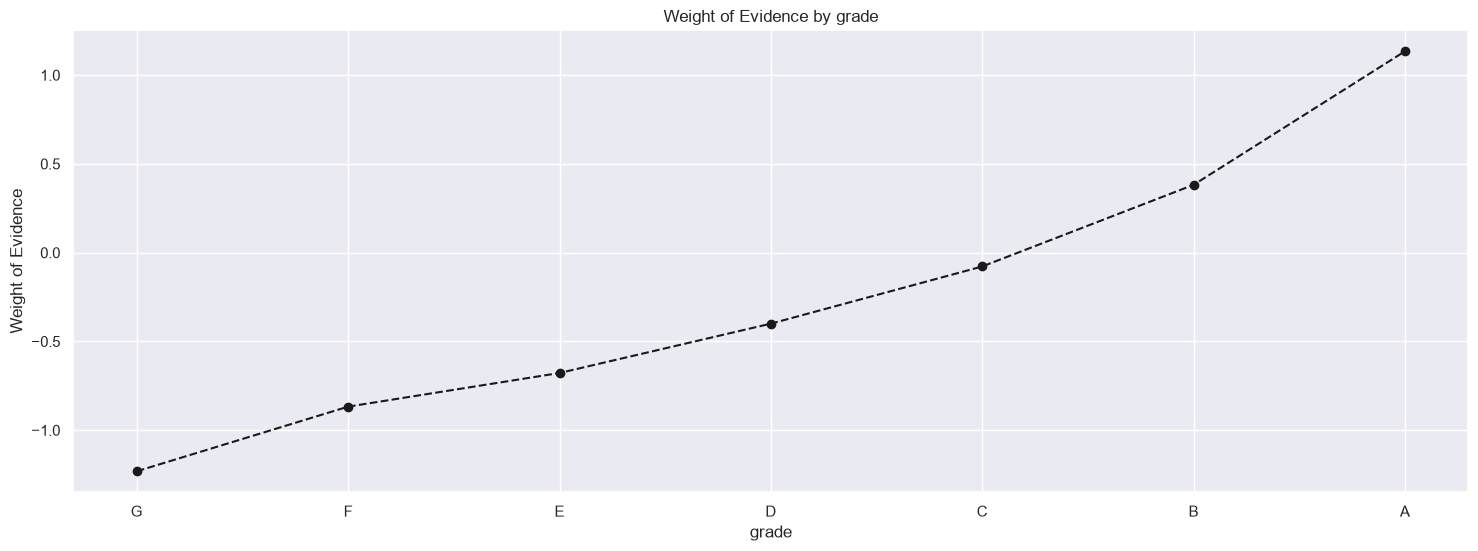

In [792]:
# To make prettier graphs
sns.set()
# Function
def plot_by_woe(
        df_WOE: pd.DataFrame,
        rotation_of_x_axis_labels: int=0
        ):
    
    # Define the plot variables
    x = np.array(df_WOE.iloc[:,0]).astype(str) # Let's get the categories and keeping as strings
    y = df_WOE['WoE']

    # Put some format
    plt.figure(figsize= (18,6))
    plt.plot(x,y, marker = 'o', linestyle ='--', color = 'k')
    plt.xlabel(df_WOE.columns[0])
    plt.ylabel("Weight of Evidence")
    plt.title(str("Weight of Evidence by " + df_WOE.columns[0]))
    plt.xticks(rotation = rotation_of_x_axis_labels)

# Plot
grade_WoE_plot = plot_by_woe(grade_WoE_IV)


In [793]:
# ========= List of dummy variables ==================
# grade
print([f"grade:{x}" for x in sorted(loans_data_w_dummies["grade"].unique())])
# home_ownership
print([f"home_ownership:{x}" for x in sorted(loans_data_w_dummies["home_ownership"].unique())])
# state of the borrower: addr_state
print([f"addr_state:{x}" for x in sorted(loans_data_w_dummies["addr_state"].unique())])


# UPDATED LIST FOR OUR MODEL USAGE =======>
# ['grade:A', 'grade:B', 'grade:C', 'grade:D', 'grade:E', 'grade:F', 'grade:G']
# ['home_ownership:RENT_OTHER_NONE_ANY', 'home_ownership:MORTGAGE', 'home_ownership:OWN']
# ['addr_state:NE_IA_NV_FL_HI_AL', 'addr_state:NM_VA', 'addr_state:OK_TN_MO_LA_MD_NC', 'addr_state:UT_KY_AZ_NJ', 'addr_state:AR_MI_PA_OH_MN', 'addr_state:RI_MA_DE_SD_IN', 'addr_state:GA_WA_OR', 'addr_state:WI_MT', 'addr_state:IL_CT', 'addr_state:KS_SC_CO_VT_AK_MS', 'addr_state:WV_NH_WY_DC_ME_ID']
# ['verification_status:Verified', 'verification_status:Source Verified', 'Not Verified]
# ['purpose:educ__sm_b__wedd__ren_en__mov__house', 'purpose:oth__med__vacation', 'purpose:major_purch__car__home_impr']
# ['initial_list_status:f', 'initial_list_status:w']

# UPDATED LIST OF REFERENCE CATEGORIES ========>
# 'grade:G'
# 'home_ownership:RENT_OTHER_NONE_ANY'
# 'addr_state:NE_IA_NV_FL_HI_AL'
# 'verification_status:Verified'
# 'purpose:educ__sm_b__wedd__ren_en__mov__house'
# 'initial_list_status:f'

['grade:A', 'grade:B', 'grade:C', 'grade:D', 'grade:E', 'grade:F', 'grade:G']
['home_ownership:ANY', 'home_ownership:MORTGAGE', 'home_ownership:NONE', 'home_ownership:OTHER', 'home_ownership:OWN', 'home_ownership:RENT']
['addr_state:AK', 'addr_state:AL', 'addr_state:AR', 'addr_state:AZ', 'addr_state:CA', 'addr_state:CO', 'addr_state:CT', 'addr_state:DC', 'addr_state:DE', 'addr_state:FL', 'addr_state:GA', 'addr_state:HI', 'addr_state:IA', 'addr_state:ID', 'addr_state:IL', 'addr_state:IN', 'addr_state:KS', 'addr_state:KY', 'addr_state:LA', 'addr_state:MA', 'addr_state:MD', 'addr_state:ME', 'addr_state:MI', 'addr_state:MN', 'addr_state:MO', 'addr_state:MS', 'addr_state:MT', 'addr_state:NC', 'addr_state:NE', 'addr_state:NH', 'addr_state:NJ', 'addr_state:NM', 'addr_state:NV', 'addr_state:NY', 'addr_state:OH', 'addr_state:OK', 'addr_state:OR', 'addr_state:PA', 'addr_state:RI', 'addr_state:SC', 'addr_state:SD', 'addr_state:TN', 'addr_state:TX', 'addr_state:UT', 'addr_state:VA', 'addr_state:VT

  home_ownership  n_obs  prop_nondefaulted  prop_n_obs  n_nondefaulted  \
0          OTHER     45           0.777778    0.000483            35.0   
1           NONE     10           0.800000    0.000107             8.0   
2           RENT  37874           0.876168    0.406125         33184.0   
3            OWN   8409           0.889642    0.090170          7481.0   
4       MORTGAGE  46919           0.906498    0.503115         42532.0   

   n_defaulted  prop_n_nondefaulted  prop_n_defaulted       WoE  \
0         10.0             0.000420          0.000998 -0.864681   
1          2.0             0.000096          0.000200 -0.731150   
2       4690.0             0.398654          0.468204 -0.160809   
3        928.0             0.089873          0.092643 -0.030354   
4       4387.0             0.510956          0.437955  0.154167   

   diff_prop_nondefaulted  diff_WoE        IV  
0                     NaN       NaN  0.023098  
1                0.022222  0.133531  0.023098  
2       

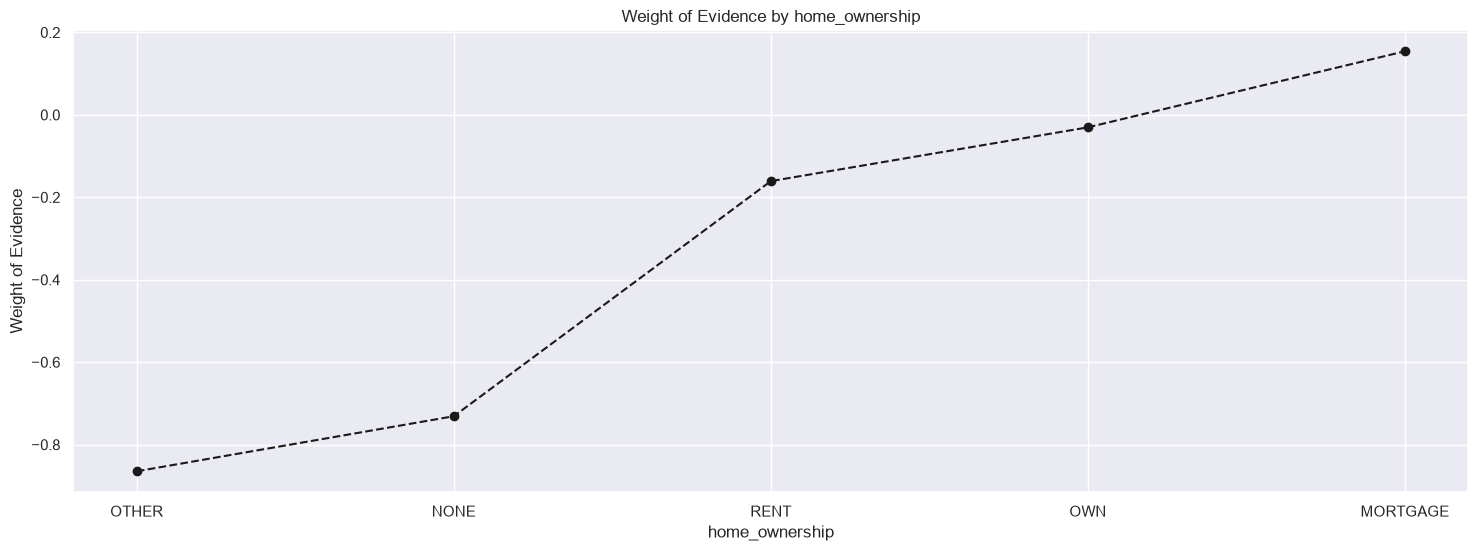

In [794]:
# Home_ownership
column_checked = "home_ownership"
home_ownership_WoE_IV = WOE_AND_IV(df_inputs=df_inputs, input_col_name=column_checked, df_output=df_output)
print(home_ownership_WoE_IV)
# Plot
home_ownership_WoE_plot = plot_by_woe(home_ownership_WoE_IV)

In [795]:
# Let's combine categories: OTHER, NONE, ANY (all having a negative WoE)
# With the next most negative WoE: RENT
# The sum can be done, because each of the dommy columns created per variable has only one 1 per column!
df_inputs_prepr['home_ownership:RENT_OTHER_NONE_ANY'] = sum([df_inputs_prepr["home_ownership:RENT"],
                                                            df_inputs_prepr["home_ownership:OTHER"],
                                                            df_inputs_prepr["home_ownership:NONE"],
                                                            df_inputs_prepr["home_ownership:ANY"]])

c:\Users\jluyandosanchez\Documents\ANACONDA\envs\credit_risk_course\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


   addr_state  n_obs  prop_nondefaulted  prop_n_obs  n_nondefaulted  \
0          NE      1           0.000000    0.000011             0.0   
1          ID      2           0.500000    0.000021             1.0   
2          NV   1298           0.859784    0.013919          1116.0   
3          HI    486           0.862140    0.005211           419.0   
4          FL   6426           0.872549    0.068906          5607.0   
5          AL   1182           0.873942    0.012675          1033.0   
6          LA   1130           0.876991    0.012117           991.0   
7          NJ   3676           0.877584    0.039418          3226.0   
8          RI    403           0.880893    0.004321           355.0   
9          NY   8031           0.881086    0.086117          7076.0   
10         MI   2358           0.882952    0.025285          2082.0   
11         NC   2478           0.883374    0.026572          2189.0   
12         DE    208           0.884615    0.002230           184.0   
13    

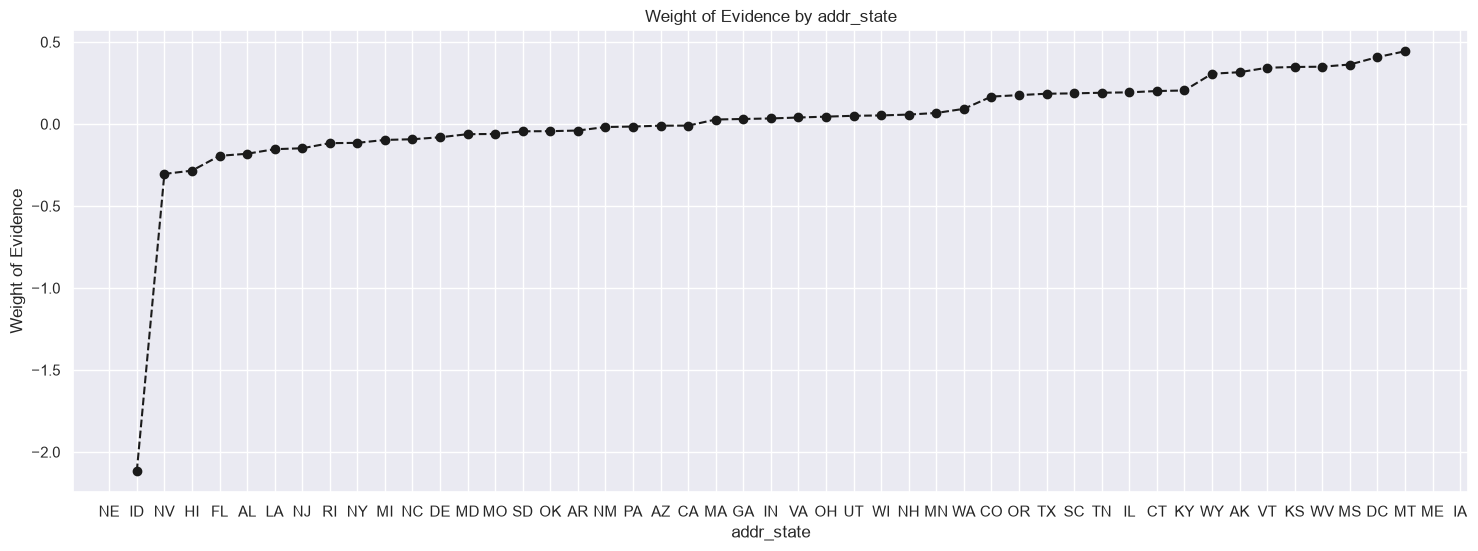

In [796]:
# state
column_checked = "addr_state"
addr_state_WoE_IV = WOE_AND_IV(df_inputs=df_inputs, input_col_name=column_checked, df_output=df_output)
print(addr_state_WoE_IV)
# Plot
addr_state_WoE_plot = plot_by_woe(addr_state_WoE_IV)

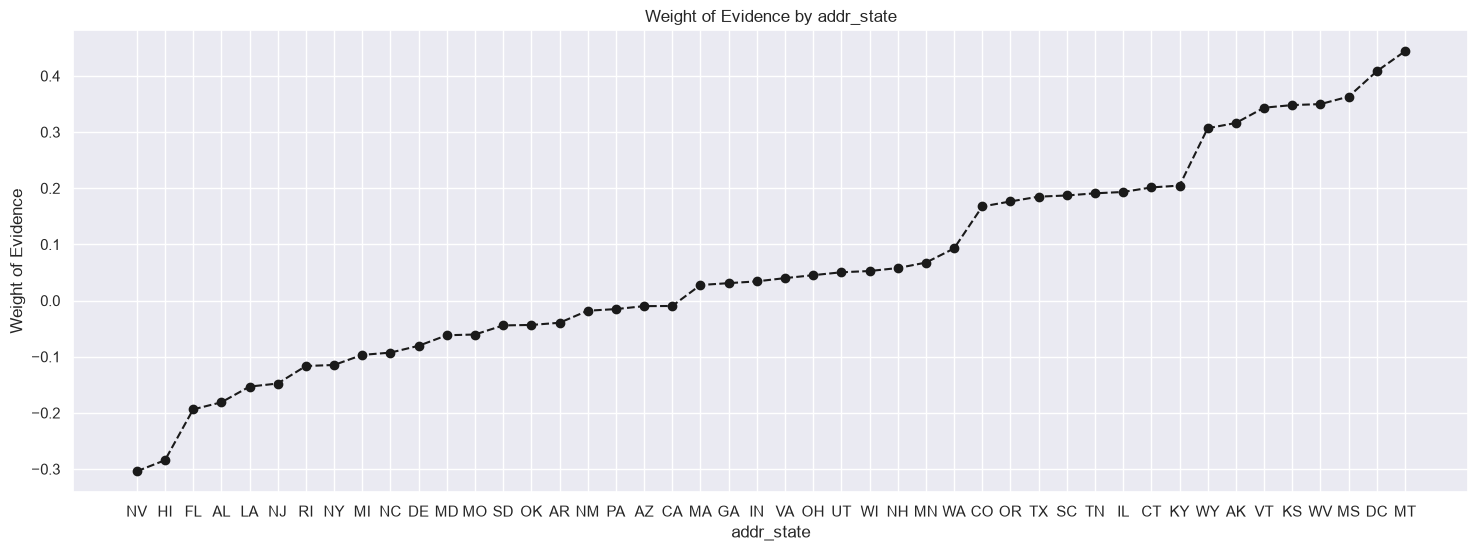

In [797]:
# We have two quite negative outliers and two positive outliers
# Let's take them out of the plot
# Plot
addr_state_WoE_plot = plot_by_woe(addr_state_WoE_IV.iloc[2:-2,:])

In [798]:
# CRITERIA TO COMBINE CATEGORIES: 
# 1. Low difference in WoE
# 2. If the difference is a bit higher, but the amount of obs is low, 
# it may be combine with an adjacent category
# NOTE 1: if two categories have a high volume of observations
# even if their WoE is close to one another, it is better to keep them separate
# otherwise the model looses explanation power by category
# NOTE 2: Better just to combine adjacent categories

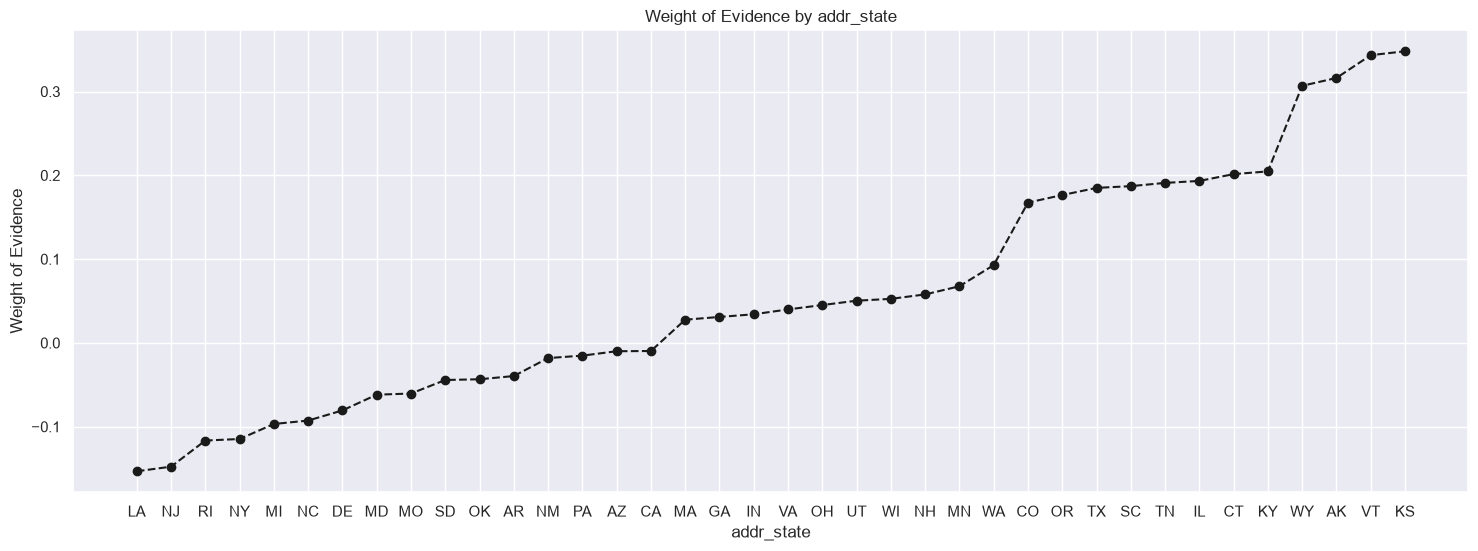

In [799]:
# We will combine the first 6 states and the last 6 states
# Let's do a plto without them
# Plot
addr_state_WoE_plot = plot_by_woe(addr_state_WoE_IV.iloc[6:-6,:])

In [800]:
# df_inputs_prepr['addr_state:ND_NE_IA_NV_FL_HI_AL'] = sum([df_inputs_prepr['addr_state:ND'], df_inputs_prepr['addr_state:NE'],
#                                                          df_inputs_prepr['addr_state:IA'], df_inputs_prepr['addr_state:NV'],
#                                                          df_inputs_prepr['addr_state:FL'], df_inputs_prepr['addr_state:HI'],
#                                                          df_inputs_prepr['addr_state:AL']])

df_inputs_prepr['addr_state:NE_IA_NV_FL_HI_AL'] = sum([df_inputs_prepr['addr_state:NE'],
                                                         df_inputs_prepr['addr_state:IA'], df_inputs_prepr['addr_state:NV'],
                                                         df_inputs_prepr['addr_state:FL'], df_inputs_prepr['addr_state:HI'],
                                                         df_inputs_prepr['addr_state:AL']])

df_inputs_prepr['addr_state:NM_VA'] = sum([df_inputs_prepr['addr_state:NM'], df_inputs_prepr['addr_state:VA']])

df_inputs_prepr['addr_state:OK_TN_MO_LA_MD_NC'] = sum([df_inputs_prepr['addr_state:OK'], df_inputs_prepr['addr_state:TN'],
                                              df_inputs_prepr['addr_state:MO'], df_inputs_prepr['addr_state:LA'],
                                              df_inputs_prepr['addr_state:MD'], df_inputs_prepr['addr_state:NC']])

df_inputs_prepr['addr_state:UT_KY_AZ_NJ'] = sum([df_inputs_prepr['addr_state:UT'], df_inputs_prepr['addr_state:KY'],
                                              df_inputs_prepr['addr_state:AZ'], df_inputs_prepr['addr_state:NJ']])

df_inputs_prepr['addr_state:AR_MI_PA_OH_MN'] = sum([df_inputs_prepr['addr_state:AR'], df_inputs_prepr['addr_state:MI'],
                                              df_inputs_prepr['addr_state:PA'], df_inputs_prepr['addr_state:OH'],
                                              df_inputs_prepr['addr_state:MN']])

df_inputs_prepr['addr_state:RI_MA_DE_SD_IN'] = sum([df_inputs_prepr['addr_state:RI'], df_inputs_prepr['addr_state:MA'],
                                              df_inputs_prepr['addr_state:DE'], df_inputs_prepr['addr_state:SD'],
                                              df_inputs_prepr['addr_state:IN']])

df_inputs_prepr['addr_state:GA_WA_OR'] = sum([df_inputs_prepr['addr_state:GA'], df_inputs_prepr['addr_state:WA'],
                                              df_inputs_prepr['addr_state:OR']])

df_inputs_prepr['addr_state:WI_MT'] = sum([df_inputs_prepr['addr_state:WI'], df_inputs_prepr['addr_state:MT']])

df_inputs_prepr['addr_state:IL_CT'] = sum([df_inputs_prepr['addr_state:IL'], df_inputs_prepr['addr_state:CT']])

df_inputs_prepr['addr_state:KS_SC_CO_VT_AK_MS'] = sum([df_inputs_prepr['addr_state:KS'], df_inputs_prepr['addr_state:SC'],
                                              df_inputs_prepr['addr_state:CO'], df_inputs_prepr['addr_state:VT'],
                                              df_inputs_prepr['addr_state:AK'], df_inputs_prepr['addr_state:MS']])

df_inputs_prepr['addr_state:WV_NH_WY_DC_ME_ID'] = sum([df_inputs_prepr['addr_state:WV'], df_inputs_prepr['addr_state:NH'],
                                              df_inputs_prepr['addr_state:WY'], df_inputs_prepr['addr_state:DC'],
                                              df_inputs_prepr['addr_state:ME'], df_inputs_prepr['addr_state:ID']])

  verification_status  n_obs  prop_nondefaulted  prop_n_obs  n_nondefaulted  \
0            Verified  33641           0.874379    0.360734         29415.0   
1     Source Verified  29963           0.897707    0.321295         26898.0   
2        Not Verified  29653           0.908070    0.317971         26927.0   

   n_defaulted  prop_n_nondefaulted  prop_n_defaulted       WoE  \
0       4226.0             0.353376          0.421883 -0.177196   
1       3065.0             0.323138          0.305980  0.054560   
2       2726.0             0.323486          0.272137  0.172850   

   diff_prop_nondefaulted  diff_WoE        IV  
0                     NaN       NaN  0.021951  
1                0.023328  0.231756  0.021951  
2                0.010363  0.118290  0.021951  


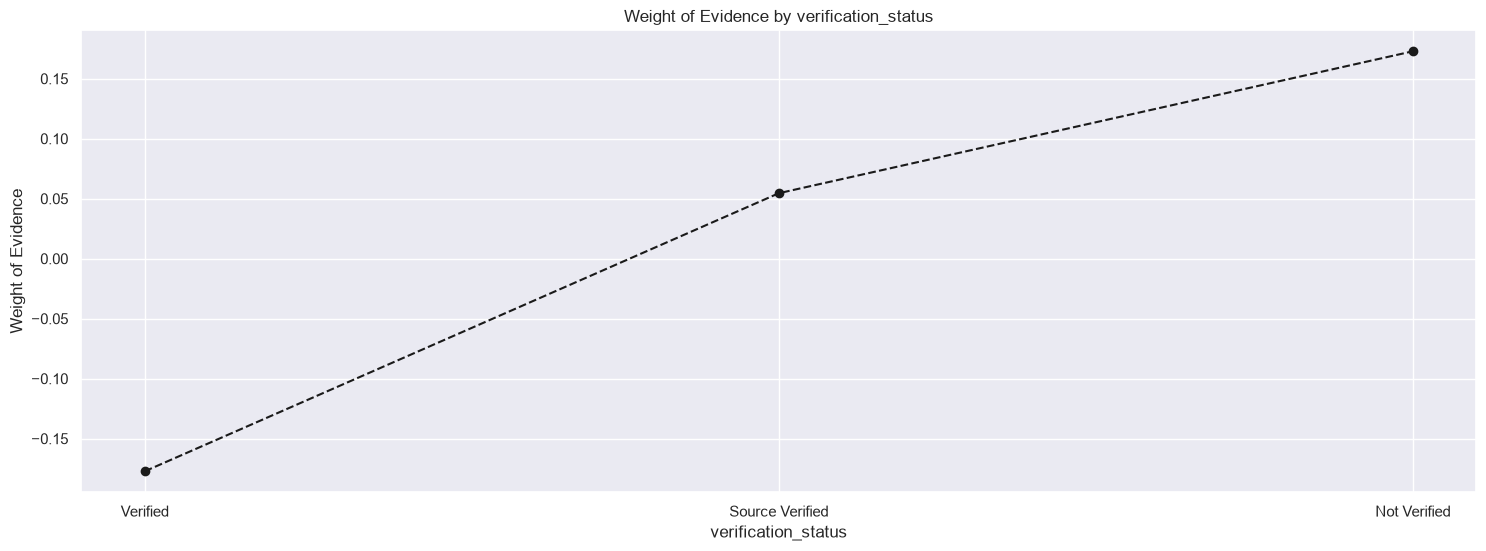

In [801]:
# ‘verification_status’
column_checked = "verification_status"
verification_status_WoE_IV = WOE_AND_IV(df_inputs=df_inputs, input_col_name=column_checked, df_output=df_output)
print(verification_status_WoE_IV)
# Plot
verification_status_WoE_plot = plot_by_woe(verification_status_WoE_IV)

# NOTHING TO CHANGE

               purpose  n_obs  prop_nondefaulted  prop_n_obs  n_nondefaulted  \
0          educational     89           0.752809    0.000954            67.0   
1     renewable_energy     70           0.771429    0.000751            54.0   
2       small_business   1431           0.778477    0.015345          1114.0   
3              medical    918           0.860566    0.009844           790.0   
4                house    439           0.861048    0.004707           378.0   
5              wedding    456           0.864035    0.004890           394.0   
6                other   4806           0.864128    0.051535          4153.0   
7               moving    602           0.882060    0.006455           531.0   
8             vacation    496           0.883065    0.005319           438.0   
9   debt_consolidation  55012           0.887879    0.589897         48844.0   
10      major_purchase   1991           0.901557    0.021350          1795.0   
11    home_improvement   5299           

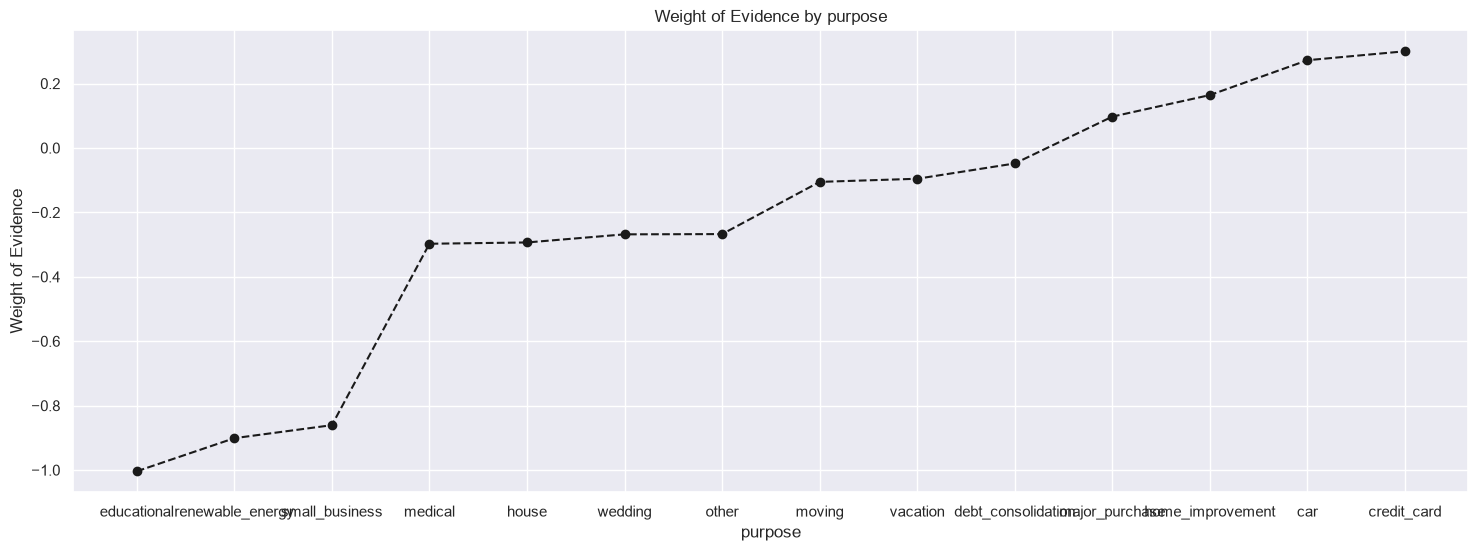

In [802]:
# ‘purpose’
column_checked = "purpose"
purpose_WoE_IV = WOE_AND_IV(df_inputs=df_inputs, input_col_name=column_checked, df_output=df_output)
print(purpose_WoE_IV)
# Plot
purpose_WoE_plot = plot_by_woe(purpose_WoE_IV)

In [803]:
df_inputs_prepr['purpose:educ__sm_b__wedd__ren_en__mov__house'] = sum([df_inputs_prepr['purpose:educational'], df_inputs_prepr['purpose:small_business'],
                                                                 df_inputs_prepr['purpose:wedding'], df_inputs_prepr['purpose:renewable_energy'],
                                                                 df_inputs_prepr['purpose:moving'], df_inputs_prepr['purpose:house']])
df_inputs_prepr['purpose:oth__med__vacation'] = sum([df_inputs_prepr['purpose:other'], df_inputs_prepr['purpose:medical'],
                                             df_inputs_prepr['purpose:vacation']])
df_inputs_prepr['purpose:major_purch__car__home_impr'] = sum([df_inputs_prepr['purpose:major_purchase'], df_inputs_prepr['purpose:car'],
                                                        df_inputs_prepr['purpose:home_improvement']])

  initial_list_status  n_obs  prop_nondefaulted  prop_n_obs  n_nondefaulted  \
0                   f  60491           0.881189    0.648648         53304.0   
1                   w  32766           0.913630    0.351352         29936.0   

   n_defaulted  prop_n_nondefaulted  prop_n_defaulted       WoE  \
0       7187.0             0.640365           0.71748 -0.113707   
1       2830.0             0.359635           0.28252  0.241341   

   diff_prop_nondefaulted  diff_WoE       IV  
0                     NaN       NaN  0.02738  
1                0.032441  0.355048  0.02738  


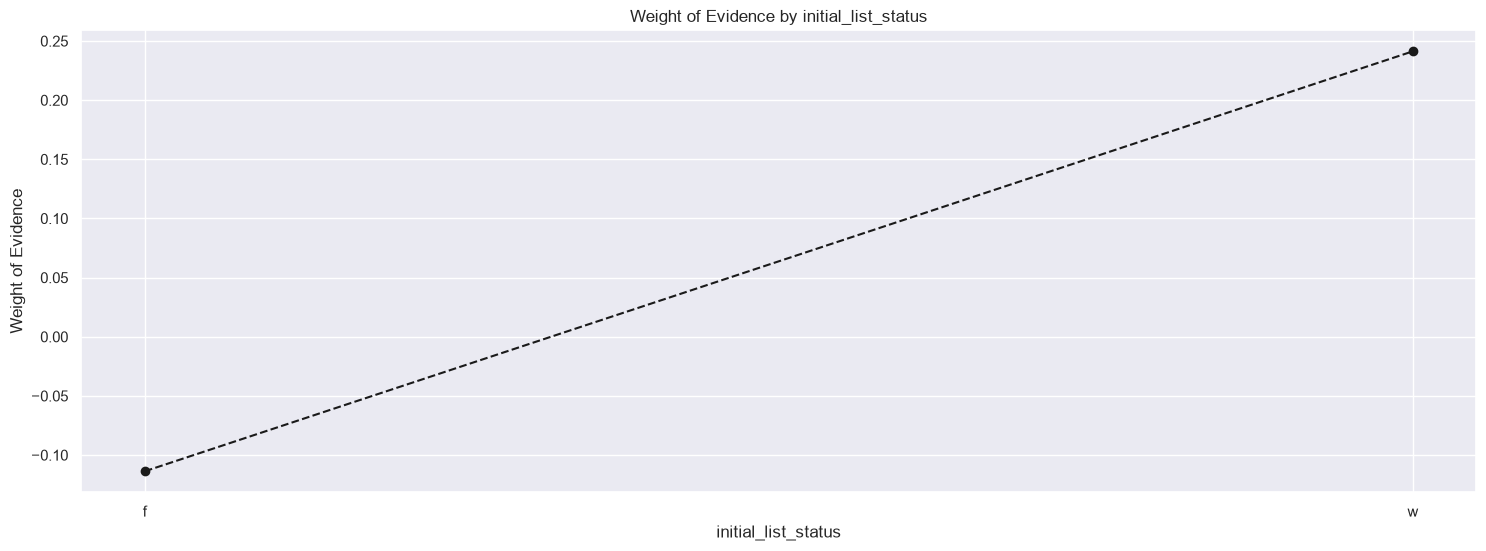

In [804]:
# ‘initial_list_status’
column_checked = "initial_list_status"
initial_list_status_WoE_IV = WOE_AND_IV(df_inputs=df_inputs, input_col_name=column_checked, df_output=df_output)
print(initial_list_status_WoE_IV)
# Plot
initial_list_status_WoE_plot = plot_by_woe(initial_list_status_WoE_IV)

# Nothing to change

Let's transform our WoE and IV calculation fucntion to accomodate also continous variables

In [805]:
# Writting a function that performs this automatically
def WOE_AND_IV_updated(
        df_inputs: pd.DataFrame, # the df including the input variable we want to check
        input_col_name: str, # the name of the input column we would like to check and that contains the categories in which our analysis will be split
        df_output: pd.DataFrame, # here the output variable, in our case with the info of the defaults
        discrete: bool # in case we have a discrete variable
):

    # Let's get a data frame in which we only have the output variable and the grades/ratings
    df1 = pd.concat([df_inputs[input_col_name], df_output], axis=1) # axis=1 concatenate columns

    # ==================== Let's calculate the Weight of Evidence (WoE) ==========================
    
    # Group by grade and count the rows per grade
    df1.groupby(df1.columns.values[0], as_index=False)[df1.columns.values[1]].count()

    # We also need the proportion of defaulted/non-defaulted borrowers per group
    # Let's get the proportion of non_defaults and as we have 1 (non default), 0 (default) we can take the average
    df1.groupby(df1.columns.values[0], as_index=False)[df1.columns.values[1]].mean()

    # Merge the two resukts into one data frame
    df1 = pd.concat([df1.groupby(df1.columns.values[0], as_index=False)[df1.columns.values[1]].count(), 
                    df1.groupby(df1.columns.values[0], as_index=False)[df1.columns.values[1]].mean()],
                    axis=1
                    )
    # MISCELLANEOUS ===================================================
    # Not to get two times grade column
    df1 = df1.iloc[:, [0,1,3]]
    # Change the names of the columns
    df1.columns = [df1.columns.values[0], 'n_obs', 'prop_nondefaulted']
    # ==================================================================

    # Get the necesary calculations to get the WoE ============>

    # Get the proportion of number of observations
    df1['prop_n_obs'] = df1.n_obs/df1.n_obs.sum()
    # Calculate the number of non-defaulted and defaulted borrowers per group
    df1['n_nondefaulted'] = df1.prop_nondefaulted * df1.n_obs
    df1['n_defaulted'] = (1-df1.prop_nondefaulted) * df1.n_obs
    # Calculate the propensity of non-defaulted and defaulted borrowers
    df1['prop_n_nondefaulted'] = df1.n_nondefaulted / df1.n_nondefaulted.sum()
    df1['prop_n_defaulted'] = df1.n_defaulted / df1.n_defaulted.sum()

    # Get the Weight of Evidence ============>
    df1['WoE'] = np.log(df1['prop_n_nondefaulted']/df1['prop_n_defaulted'])

    # If the variable is discrete, please sorth the values per WoE 
    if discrete:
        df1 = df1.sort_values(['WoE'])
        df1 = df1.reset_index(drop=True)

    # Get the differences of two subsequent rows, abs() to see the net effect
    df1['diff_prop_nondefaulted'] = df1.prop_nondefaulted.diff().abs()
    df1['diff_WoE'] = df1.WoE.diff().abs()

    # ==================== Let's calculate the Information Value (IV) ==========================
    df1['IV'] = (df1.prop_n_nondefaulted - df1.prop_n_defaulted) * df1.WoE
    df1['IV'] = df1['IV'].sum() # All categories get the same value, because IV acts per variable
    
    return df1

In [806]:
# UPDATED LIST FOR OUR MODEL USAGE =======>

# DISCRETE ==>
# ['grade:A', 'grade:B', 'grade:C', 'grade:D', 'grade:E', 'grade:F', 'grade:G']
# ['home_ownership:RENT_OTHER_NONE_ANY', 'home_ownership:MORTGAGE', 'home_ownership:OWN']
# ['addr_state:NE_IA_NV_FL_HI_AL', 'addr_state:NM_VA', 'addr_state:OK_TN_MO_LA_MD_NC', 'addr_state:UT_KY_AZ_NJ', 'addr_state:AR_MI_PA_OH_MN', 'addr_state:RI_MA_DE_SD_IN', 'addr_state:GA_WA_OR', 'addr_state:WI_MT', 'addr_state:IL_CT', 'addr_state:KS_SC_CO_VT_AK_MS', 'addr_state:WV_NH_WY_DC_ME_ID']
# ['verification_status:Verified', 'verification_status:Source Verified', 'Not Verified]
# ['purpose:educ__sm_b__wedd__ren_en__mov__house', 'purpose:oth__med__vacation', 'purpose:major_purch__car__home_impr']
# ['initial_list_status:f', 'initial_list_status:w']

# CONTINOUS ==>
# ['term:36', 'term:60']
# ['emp_length:0', 'emp_length:1', 'emp_length:2-4', 'emp_length:5-6', 'emp_length:7-9', 'emp_length:10']

# UPDATED LIST OF REFERENCE CATEGORIES ========>

# DISCRETE ==>
# 'grade:G'
# 'home_ownership:RENT_OTHER_NONE_ANY'
# 'addr_state:NE_IA_NV_FL_HI_AL'
# 'verification_status:Verified'
# 'purpose:educ__sm_b__wedd__ren_en__mov__house'
# 'initial_list_status:f'

# CONTINOUS ==>
# 'term:60'
# 'emp_length:0'

   term_int  n_obs  prop_nondefaulted  prop_n_obs  n_nondefaulted  \
0        36  67534           0.904108    0.724171         61058.0   
1        60  25723           0.862341    0.275829         22182.0   

   n_defaulted  prop_n_nondefaulted  prop_n_defaulted       WoE  \
0       6476.0             0.733518          0.646501  0.126277   
1       3541.0             0.266482          0.353499 -0.282572   

   diff_prop_nondefaulted  diff_WoE        IV  
0                     NaN       NaN  0.035577  
1                0.041766  0.408849  0.035577  


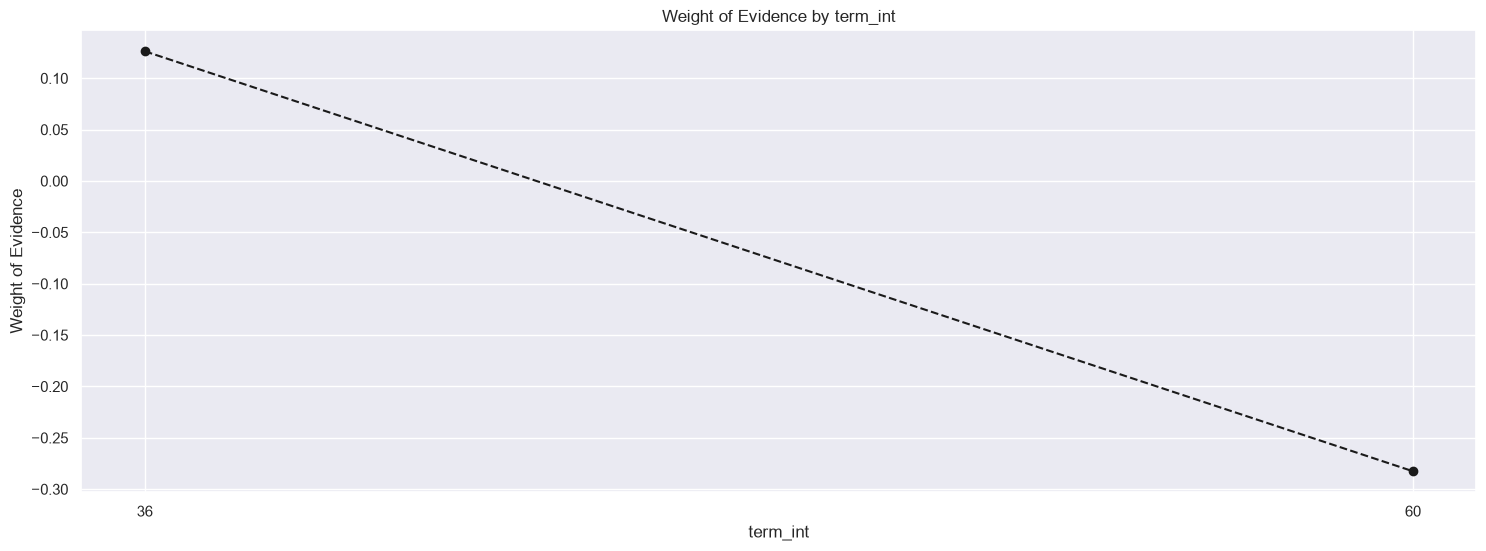

In [807]:
# variable 'term_int'
column_checked = "term_int"
term_int_WoE_IV = WOE_AND_IV_updated(df_inputs=df_inputs, input_col_name=column_checked, df_output=df_output, discrete=False)
print(term_int_WoE_IV)
# Plot
term_int_WoE_plot = plot_by_woe(term_int_WoE_IV)

In [808]:
# Create the dummy variables --- as we have only two values, when value is not 36, then it is 60
df_inputs_prepr['term:36'] = np.where(df_inputs_prepr['term_int'] == 36, 1, 0)
df_inputs_prepr['term:60'] = np.where(df_inputs_prepr['term_int'] == 60, 1, 0)

    emp_length_int  n_obs  prop_nondefaulted  prop_n_obs  n_nondefaulted  \
0                0  11553           0.876655    0.123883         10128.0   
1                1   5968           0.894102    0.063995          5336.0   
2                2   8295           0.889210    0.088948          7376.0   
3                3   7391           0.891354    0.079254          6588.0   
4                4   5555           0.891629    0.059567          4953.0   
5                5   6172           0.887233    0.066183          5476.0   
6                6   5225           0.880766    0.056028          4602.0   
7                7   5131           0.895537    0.055020          4595.0   
8                8   4542           0.893879    0.048704          4060.0   
9                9   3621           0.893676    0.038828          3236.0   
10              10  29804           0.902228    0.319590         26890.0   

    n_defaulted  prop_n_nondefaulted  prop_n_defaulted       WoE  \
0        1425.0    

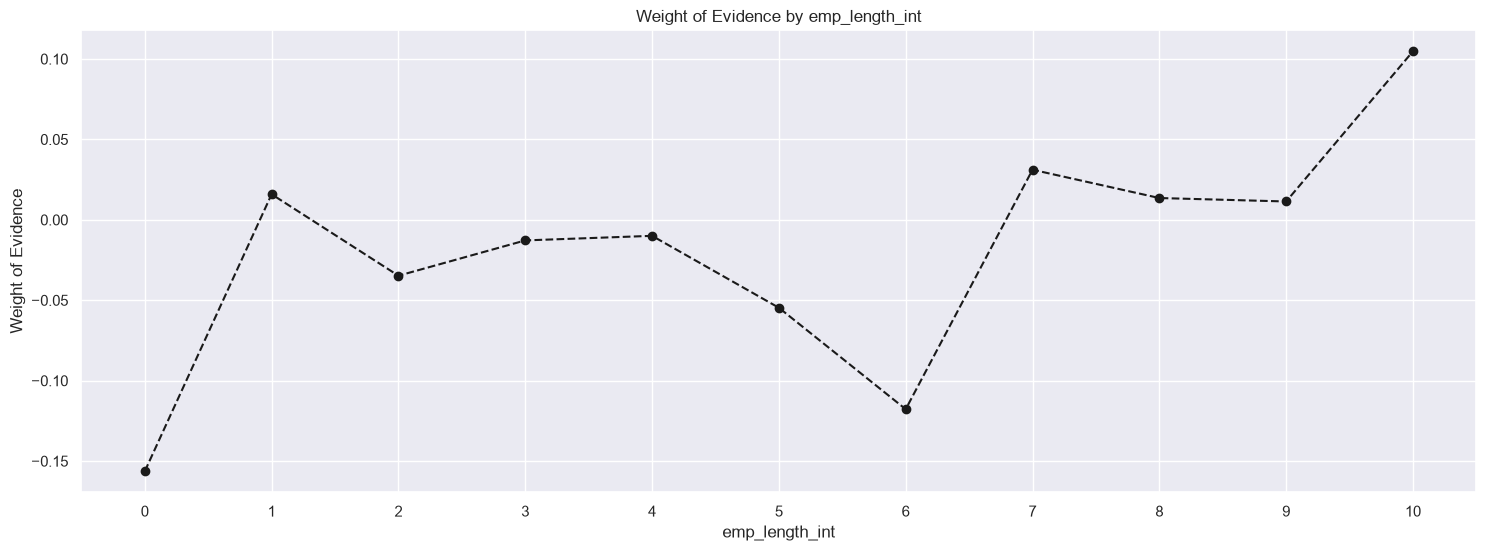

In [809]:
# variable 'term_int'
column_checked = "emp_length_int"
emp_length_int_WoE_IV = WOE_AND_IV_updated(df_inputs=df_inputs, input_col_name=column_checked, df_output=df_output, discrete=False)
print(emp_length_int_WoE_IV)
# Plot
emp_length_int_WoE_plot = plot_by_woe(emp_length_int_WoE_IV)

In [810]:
df_inputs_prepr['emp_length:0'] = np.where(df_inputs_prepr['emp_length_int'].isin([0]), 1, 0)
df_inputs_prepr['emp_length:1'] = np.where(df_inputs_prepr['emp_length_int'].isin([1]), 1, 0)
df_inputs_prepr['emp_length:2-4'] = np.where(df_inputs_prepr['emp_length_int'].isin(range(2, 5)), 1, 0)
df_inputs_prepr['emp_length:5-6'] = np.where(df_inputs_prepr['emp_length_int'].isin(range(5, 7)), 1, 0)
df_inputs_prepr['emp_length:7-9'] = np.where(df_inputs_prepr['emp_length_int'].isin(range(7, 10)), 1, 0)
df_inputs_prepr['emp_length:10'] = np.where(df_inputs_prepr['emp_length_int'].isin([10]), 1, 0)

Let's do now FINE CLASSING - mths_since_issue_d

In [811]:
df_inputs_prepr.mths_since_issue_d.unique()

array([ 41.,  38.,  66.,  37.,  58.,  50.,  86.,  51.,  48.,  59.,  72.,
        77.,  47.,  46.,  56.,  55., 119.,  63., 102.,  39.,  53.,  40.,
        52.,  43.,  49.,  57.,  45.,  36.,  54.,  74.,  44.,  73., 103.,
        70.,  95.,  89.,  68.,  82.,  71.,  76., 104.,  65.,  80.,  91.,
        75.,  67.,  42.,  61.,  64.,  60.,  85.,  88., 110.,  96.,  78.,
        83.,  69.,  90.,  62., 108.,  79.,  92., 118.,  99.,  81., 115.,
        97., 114., 116., 100.,  93., 117., 106., 124., 101., 125.,  87.,
        84.,  94., 105., 109.,  98., 107., 112., 113., 122., 111., 120.,
       121., 123., 126.])

In [812]:
# This variable is categorical, split in 50 categories
df_inputs_prepr['mths_since_issue_d_factor'] = pd.cut(df_inputs_prepr.mths_since_issue_d, 50)
df_inputs_prepr['mths_since_issue_d_factor']

362514     (39.6, 41.4]
288564     (37.8, 39.6]
213591     (64.8, 66.6]
263083    (35.91, 37.8]
165001     (57.6, 59.4]
              ...      
115        (70.2, 72.0]
296284     (37.8, 39.6]
61777      (48.6, 50.4]
91763      (50.4, 52.2]
167512     (57.6, 59.4]
Name: mths_since_issue_d_factor, Length: 93257, dtype: category
Categories (50, interval[float64, right]): [(35.91, 37.8] < (37.8, 39.6] < (39.6, 41.4] < (41.4, 43.2] ... (118.8, 120.6] < (120.6, 122.4] < (122.4, 124.2] < (124.2, 126.0]]

   mths_since_issue_d_factor  n_obs  prop_nondefaulted  prop_n_obs  \
0              (35.91, 37.8]   7191           0.947573    0.077109   
1               (37.8, 39.6]   9752           0.932629    0.104571   
2               (39.6, 41.4]   9506           0.923732    0.101933   
3               (41.4, 43.2]   7240           0.911878    0.077635   
4               (43.2, 45.0]   7217           0.905224    0.077388   
5               (45.0, 46.8]   3104           0.900451    0.033284   
6               (46.8, 48.6]   6197           0.892529    0.066451   
7               (48.6, 50.4]   5821           0.887305    0.062419   
8               (50.4, 52.2]   5021           0.880104    0.053840   
9               (52.2, 54.0]   4497           0.875917    0.048222   
10              (54.0, 55.8]   2064           0.867733    0.022132   
11              (55.8, 57.6]   3572           0.862262    0.038303   
12              (57.6, 59.4]   2904           0.851240    0.031140   
13              (59.

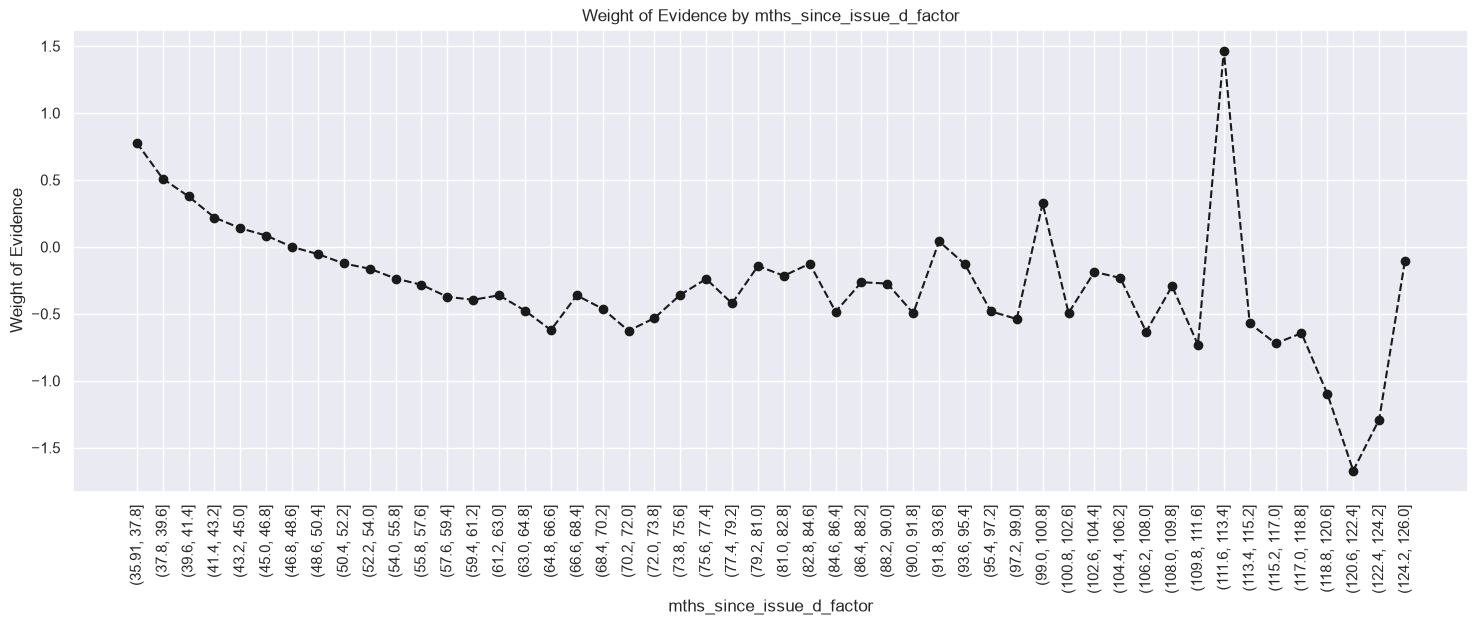

In [813]:
# variable 'term_int'
column_checked = "mths_since_issue_d_factor"
mths_since_issue_d_factor_WoE_IV = WOE_AND_IV_updated(df_inputs=df_inputs, input_col_name=column_checked, df_output=df_output, discrete=False)
print(mths_since_issue_d_factor_WoE_IV)
# Plot
mths_since_issue_d_factor_WoE_plot = plot_by_woe(mths_since_issue_d_factor_WoE_IV, 90) # 90 degrees rotation to make them vertical

NOW, lets do COARSE CLASSING - mths_since_issue_d

In [814]:
df_inputs_prepr['mths_since_issue_d:<38'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(38)), 1, 0)
df_inputs_prepr['mths_since_issue_d:38-39'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(38, 40)), 1, 0)
df_inputs_prepr['mths_since_issue_d:40-41'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(40, 42)), 1, 0)
df_inputs_prepr['mths_since_issue_d:42-48'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(42, 49)), 1, 0)
df_inputs_prepr['mths_since_issue_d:49-52'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(49, 53)), 1, 0)
df_inputs_prepr['mths_since_issue_d:53-64'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(53, 65)), 1, 0)
df_inputs_prepr['mths_since_issue_d:65-84'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(65, 85)), 1, 0)
df_inputs_prepr['mths_since_issue_d:>84'] = np.where(df_inputs_prepr['mths_since_issue_d'].isin(range(85, int(df_inputs_prepr['mths_since_issue_d'].max()))), 1, 0)

Let's do now FINE CLASSING - int_rate

In [815]:
# This variable is categorical, split in 50 categories
df_inputs_prepr['int_rate_factor'] = pd.cut(df_inputs_prepr.int_rate, 50)
df_inputs_prepr['int_rate_factor']

362514    (14.914, 15.327]
288564    (20.694, 21.106]
213591    (14.502, 14.914]
263083    (14.089, 14.502]
165001      (8.722, 9.135]
                ...       
115       (11.612, 12.025]
296284     (9.961, 10.374]
61777       (8.722, 9.135]
91763       (8.722, 9.135]
167512      (7.484, 7.897]
Name: int_rate_factor, Length: 93257, dtype: category
Categories (50, interval[float64, right]): [(5.399, 5.833] < (5.833, 6.246] < (6.246, 6.658] < (6.658, 7.071] ... (24.409, 24.822] < (24.822, 25.234] < (25.234, 25.647] < (25.647, 26.06]]

Let's do now COARSE CLASSING - int_rate

     int_rate_factor  n_obs  prop_nondefaulted  prop_n_obs  n_nondefaulted  \
0     (5.399, 5.833]    198           0.969697    0.002123           192.0   
1     (5.833, 6.246]   2086           0.979866    0.022368          2044.0   
2     (6.246, 6.658]   1974           0.972138    0.021167          1919.0   
3     (6.658, 7.071]    477           0.951782    0.005115           454.0   
4     (7.071, 7.484]    804           0.982587    0.008621           790.0   
5     (7.484, 7.897]   3245           0.966102    0.034796          3135.0   
6      (7.897, 8.31]   2429           0.951009    0.026046          2310.0   
7      (8.31, 8.722]   1680           0.967262    0.018015          1625.0   
8     (8.722, 9.135]   2384           0.942114    0.025564          2246.0   
9     (9.135, 9.548]   1590           0.977358    0.017050          1554.0   
10    (9.548, 9.961]   1881           0.934078    0.020170          1757.0   
11   (9.961, 10.374]   2766           0.937455    0.029660      

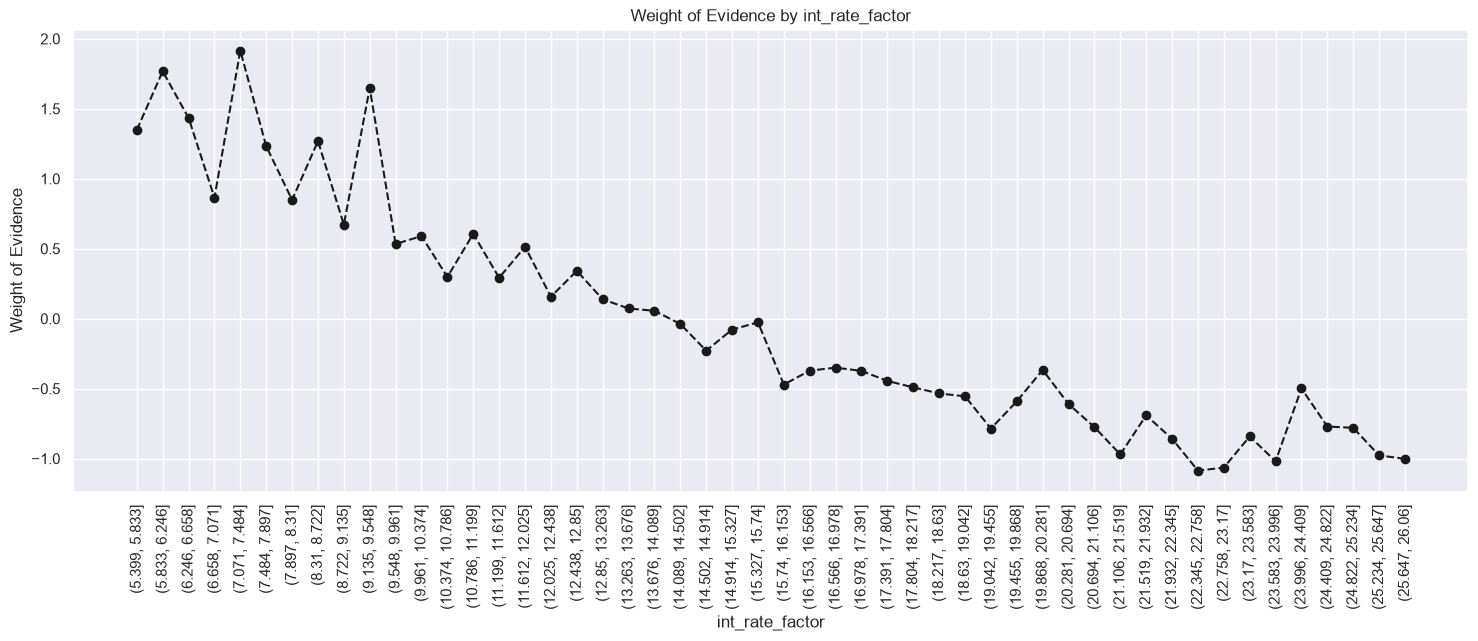

In [816]:
# variable 'term_int'
column_checked = "int_rate_factor"
int_rate_factor_WoE_IV = WOE_AND_IV_updated(df_inputs=df_inputs, input_col_name=column_checked, df_output=df_output, discrete=False)
print(int_rate_factor_WoE_IV)
# Plot
int_rate_factor_WoE_plot = plot_by_woe(int_rate_factor_WoE_IV, 90) # 90 degrees rotation to make them vertical

In [817]:
df_inputs_prepr['int_rate:<9.548'] = np.where((df_inputs_prepr['int_rate'] <= 9.548), 1, 0)
df_inputs_prepr['int_rate:9.548-12.025'] = np.where((df_inputs_prepr['int_rate'] > 9.548) & (df_inputs_prepr['int_rate'] <= 12.025), 1, 0)
df_inputs_prepr['int_rate:12.025-15.74'] = np.where((df_inputs_prepr['int_rate'] > 12.025) & (df_inputs_prepr['int_rate'] <= 15.74), 1, 0)
df_inputs_prepr['int_rate:15.74-20.281'] = np.where((df_inputs_prepr['int_rate'] > 15.74) & (df_inputs_prepr['int_rate'] <= 20.281), 1, 0)
df_inputs_prepr['int_rate:>20.281'] = np.where((df_inputs_prepr['int_rate'] > 20.281), 1, 0)

Let's do now FINE CLASSING - funded_amnt

In [818]:
# This variable is categorical, split in 50 categories
df_inputs_prepr['funded_amnt_factor'] = pd.cut(df_inputs_prepr.funded_amnt, 50)
df_inputs_prepr['funded_amnt_factor']

362514    (32240.0, 32930.0]
288564    (10850.0, 11540.0]
213591    (29480.0, 30170.0]
263083    (14300.0, 14990.0]
165001    (14990.0, 15680.0]
                 ...        
115         (7400.0, 8090.0]
296284    (23960.0, 24650.0]
61777     (34310.0, 35000.0]
91763     (17750.0, 18440.0]
167512    (15680.0, 16370.0]
Name: funded_amnt_factor, Length: 93257, dtype: category
Categories (50, interval[float64, right]): [(465.5, 1190.0] < (1190.0, 1880.0] < (1880.0, 2570.0] < (2570.0, 3260.0] ... (32240.0, 32930.0] < (32930.0, 33620.0] < (33620.0, 34310.0] < (34310.0, 35000.0]]

Let's do now COARSE CLASSING - funded_amnt

    funded_amnt_factor  n_obs  prop_nondefaulted  prop_n_obs  n_nondefaulted  \
0      (465.5, 1190.0]    319           0.880878    0.003421           281.0   
1     (1190.0, 1880.0]    800           0.897500    0.008578           718.0   
2     (1880.0, 2570.0]   1513           0.900859    0.016224          1363.0   
3     (2570.0, 3260.0]   1817           0.894882    0.019484          1626.0   
4     (3260.0, 3950.0]   1245           0.893173    0.013350          1112.0   
5     (3950.0, 4640.0]   2298           0.885117    0.024642          2034.0   
6     (4640.0, 5330.0]   3957           0.900430    0.042431          3563.0   
7     (5330.0, 6020.0]   4186           0.907549    0.044887          3799.0   
8     (6020.0, 6710.0]   1718           0.883586    0.018422          1518.0   
9     (6710.0, 7400.0]   2880           0.894792    0.030882          2577.0   
10    (7400.0, 8090.0]   4266           0.895687    0.045745          3821.0   
11    (8090.0, 8780.0]   1617           

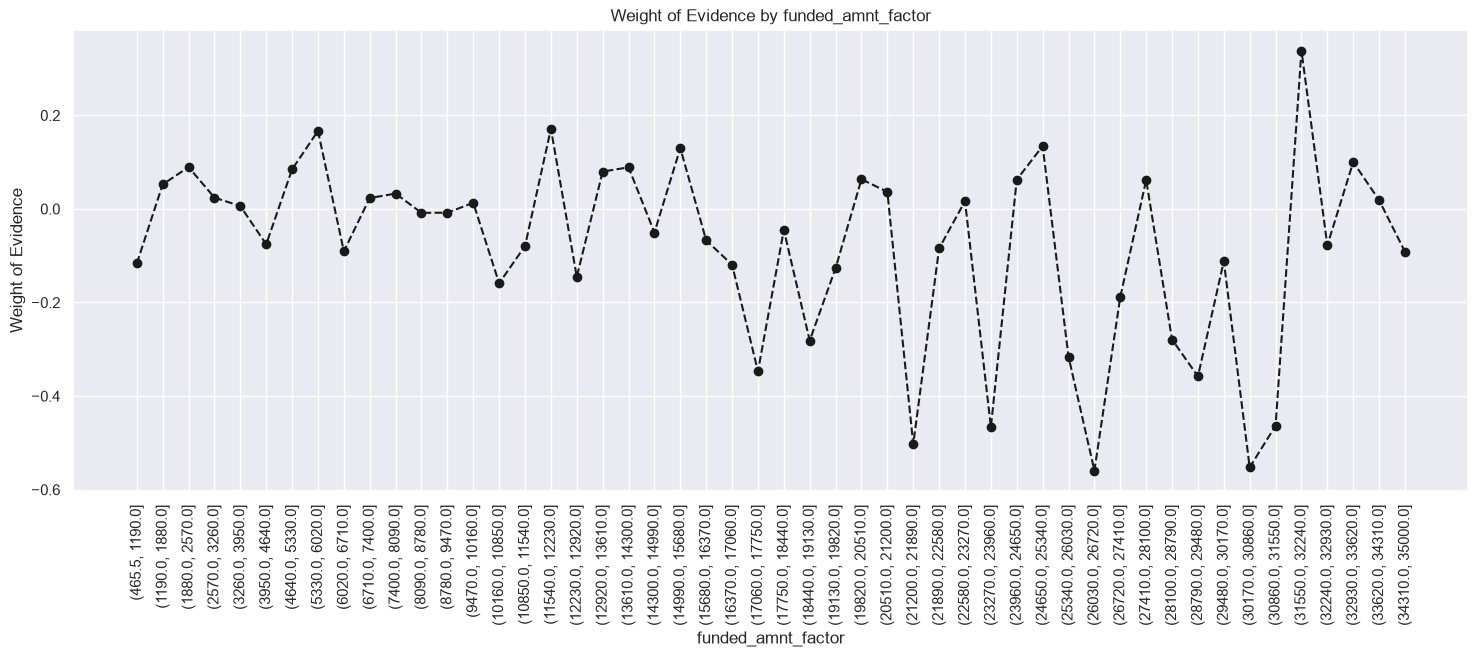

In [819]:
# variable 'term_int'
column_checked = "funded_amnt_factor"
funded_amnt_factor_WoE_IV = WOE_AND_IV_updated(df_inputs=df_inputs, input_col_name=column_checked, df_output=df_output, discrete=False)
print(funded_amnt_factor_WoE_IV)
# Plot
funded_amnt_factor_WoE_plot = plot_by_woe(funded_amnt_factor_WoE_IV, 90) # 90 degrees rotation to make them vertical

# NO CLEAR TENDENCY WITH RESPECT TO THE PROBABILITY OF DEFAULT --> Not relevant to be part of our Logistic Regression

In [820]:
# UPDATED LIST FOR OUR MODEL USAGE =======>

# DISCRETE ==>
# ['grade:A', 'grade:B', 'grade:C', 'grade:D', 'grade:E', 'grade:F', 'grade:G']
# ['home_ownership:RENT_OTHER_NONE_ANY', 'home_ownership:MORTGAGE', 'home_ownership:OWN']
# ['addr_state:NE_IA_NV_FL_HI_AL', 'addr_state:NM_VA', 'addr_state:OK_TN_MO_LA_MD_NC', 'addr_state:UT_KY_AZ_NJ', 'addr_state:AR_MI_PA_OH_MN', 'addr_state:RI_MA_DE_SD_IN', 'addr_state:GA_WA_OR', 'addr_state:WI_MT', 'addr_state:IL_CT', 'addr_state:KS_SC_CO_VT_AK_MS', 'addr_state:WV_NH_WY_DC_ME_ID']
# ['verification_status:Verified', 'verification_status:Source Verified', 'Not Verified]
# ['purpose:educ__sm_b__wedd__ren_en__mov__house', 'purpose:oth__med__vacation', 'purpose:major_purch__car__home_impr']
# ['initial_list_status:f', 'initial_list_status:w']

# CONTINOUS ==>
# ['term:36', 'term:60']
# ['emp_length:0', 'emp_length:1', 'emp_length:2-4', 'emp_length:5-6', 'emp_length:7-9', 'emp_length:10']
# ['mths_since_issue_d:<38', 'mths_since_issue_d:38-39', 'mths_since_issue_d:40-41', 'mths_since_issue_d:42-48', 'mths_since_issue_d:49-52', 'mths_since_issue_d:53-64', 'mths_since_issue_d:65-84', 'mths_since_issue_d:>84']
# ['int_rate:<9.548', 'int_rate:9.548-12.025', 'int_rate:12.025-15.74', 'int_rate:15.74-20.281', 'int_rate:>20.281']
# ['mths_since_earliest_cr_line:<140', 'mths_since_earliest_cr_line:141-164', 'mths_since_earliest_cr_line:165-247', 'mths_since_earliest_cr_line:248-270', 'mths_since_earliest_cr_line:271-352', 'mths_since_earliest_cr_line:>352']
# ['delinq_2yrs:0', 'delinq_2yrs:1-3', 'delinq_2yrs:>=4']
# ['inq_last_6mths:0', 'inq_last_6mths:1-2', 'inq_last_6mths:3-6', 'inq_last_6mths:>6']
# ['open_acc:0', 'open_acc:1-3', 'open_acc:4-12', 'open_acc:13-17', 'open_acc:18-22', 'open_acc:23-25', 'open_acc:26-30', 'open_acc:>=31']
# ['pub_rec:0-2', 'pub_rec:3-4', 'pub_rec:>=5']
# ['total_acc:<=27', 'total_acc:28-51', 'total_acc:>=52']
# ['acc_now_delinq:0', 'acc_now_delinq:>=1']
# ['total_rev_hi_lim:<=5K', 'total_rev_hi_lim:5K-10K', 'total_rev_hi_lim:10K-20K', 'total_rev_hi_lim:20K-30K', 'total_rev_hi_lim:30K-40K', 'total_rev_hi_lim:40K-55K', 'total_rev_hi_lim:55K-95K', 'total_rev_hi_lim:>95K']

# UPDATED LIST OF REFERENCE CATEGORIES ========>

# DISCRETE ==>
# 'grade:G'
# 'home_ownership:RENT_OTHER_NONE_ANY'
# 'addr_state:NE_IA_NV_FL_HI_AL'
# 'verification_status:Verified'
# 'purpose:educ__sm_b__wedd__ren_en__mov__house'
# 'initial_list_status:f'

# CONTINOUS ==>
# 'term:60'
# 'emp_length:0'
# 'mths_since_issue_d:>84'
# 'int_rate:>20.281'
# 'mths_since_earliest_cr_line:<140'
# 'delinq_2yrs:>=4'
# 'inq_last_6mths:>6'
# 'open_acc:0'
# 'pub_rec:0-2'
# 'total_acc:<=27'
# 'acc_now_delinq:0'
# 'total_rev_hi_lim:<=5K'

FINE & COARSE CLASSING FOR THE REST OF THE VARIABLES

· ‘mths_since_earliest_cr_line’;

· ‘installment’;

· ‘delinq_2yrs’;

· ‘inq_last_6mths’;

· ‘open_acc’;

· ‘pub_rec’;

· ‘total_acc’;

· ‘acc_now_delinq’

· ‘total_rev_hi_lim_factor’

   mths_since_earliest_cr_line_factor  n_obs  prop_nondefaulted  prop_n_obs  \
0                     (-0.587, 11.74]      5           1.000000    0.000054   
1                      (70.44, 82.18]    182           0.923077    0.001952   
2                      (82.18, 93.92]    508           0.915354    0.005447   
3                     (93.92, 105.66]    715           0.857343    0.007667   
4                     (105.66, 117.4]   1268           0.858833    0.013597   
5                     (117.4, 129.14]   2314           0.877701    0.024813   
6                    (129.14, 140.88]   2816           0.863281    0.030196   
7                    (140.88, 152.62]   3366           0.884433    0.036094   
8                    (152.62, 164.36]   3989           0.887440    0.042774   
9                     (164.36, 176.1]   4857           0.889850    0.052082   
10                    (176.1, 187.84]   5076           0.892435    0.054430   
11                   (187.84, 199.58]   6578        

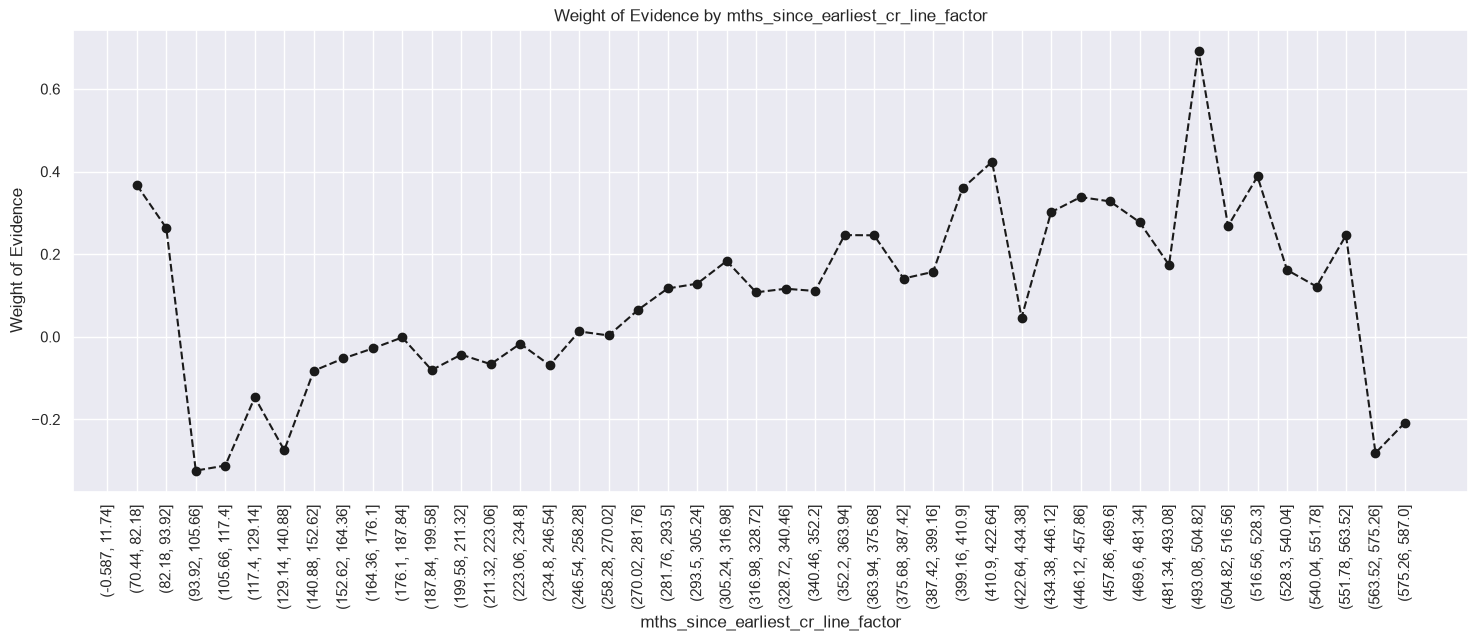

In [821]:
# ------------------------------------------------------------------------------------
# VARIABLE: mths_since_earliest_cr_line
# ------------------------------------------------------------------------------------

# This variable is categorical, split in 50 categories
df_inputs_prepr['mths_since_earliest_cr_line_factor'] = pd.cut(df_inputs_prepr.mths_since_earliest_cr_line, 50)

# variable 'term_int'
column_checked = "mths_since_earliest_cr_line_factor"
mths_since_earliest_cr_line_factor_WoE_IV = WOE_AND_IV_updated(df_inputs=df_inputs, input_col_name=column_checked, df_output=df_output, discrete=False)
print(mths_since_earliest_cr_line_factor_WoE_IV)
# Plot
mths_since_earliest_cr_line_factor_WoE_plot = plot_by_woe(mths_since_earliest_cr_line_factor_WoE_IV, 90) # 90 degrees rotation to make them vertical

In [822]:
df_inputs_prepr['mths_since_earliest_cr_line:<140'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(140)), 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:141-164'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(140, 165)), 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:165-247'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(165, 248)), 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:248-270'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(248, 271)), 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:271-352'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(271, 353)), 1, 0)
df_inputs_prepr['mths_since_earliest_cr_line:>352'] = np.where(df_inputs_prepr['mths_since_earliest_cr_line'].isin(range(353, int(df_inputs_prepr['mths_since_earliest_cr_line'].max()))), 1, 0)

     installment_factor  n_obs  prop_nondefaulted  prop_n_obs  n_nondefaulted  \
0      (14.369, 43.585]    485           0.872165    0.005201           423.0   
1       (43.585, 71.41]   1246           0.906100    0.013361          1129.0   
2       (71.41, 99.235]   1731           0.895436    0.018562          1550.0   
3      (99.235, 127.06]   2292           0.897906    0.024577          2058.0   
4     (127.06, 154.885]   2602           0.887779    0.027901          2310.0   
5     (154.885, 182.71]   4133           0.899831    0.044318          3719.0   
6     (182.71, 210.535]   4109           0.906060    0.044061          3723.0   
7     (210.535, 238.36]   3730           0.903753    0.039997          3371.0   
8     (238.36, 266.185]   4660           0.901502    0.049969          4201.0   
9     (266.185, 294.01]   4975           0.890653    0.053347          4431.0   
10    (294.01, 321.835]   5186           0.908407    0.055610          4711.0   
11    (321.835, 349.66]   64

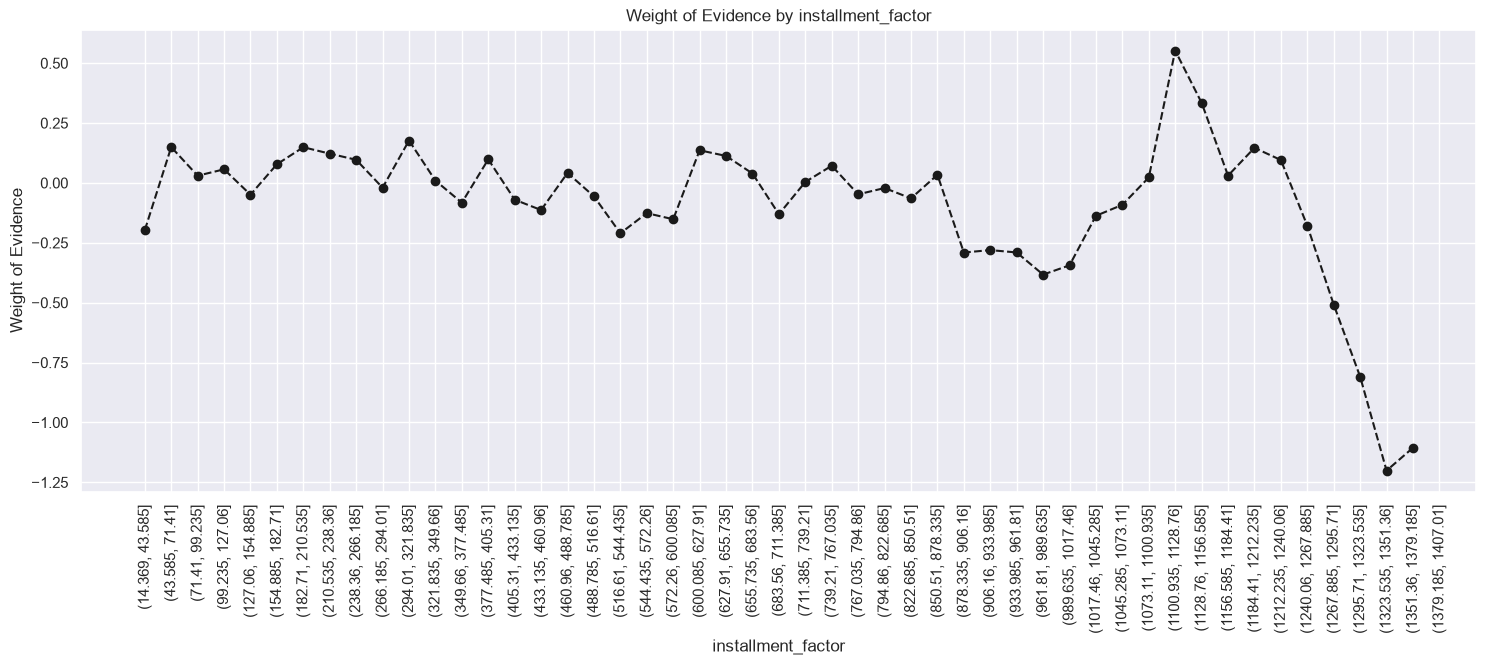

In [823]:
# ------------------------------------------------------------------------------------
# VARIABLE: installment
# ------------------------------------------------------------------------------------

# This variable is categorical, split in 50 categories
df_inputs_prepr['installment_factor'] = pd.cut(df_inputs_prepr.installment, 50)

column_checked = "installment_factor"

installment_factor_WoE_IV = WOE_AND_IV_updated(
    df_inputs=df_inputs,
    input_col_name=column_checked,
    df_output=df_output,
    discrete=False
)

print(installment_factor_WoE_IV)

# Plot
installment_factor_WoE_plot = plot_by_woe(
    installment_factor_WoE_IV,
    90
)

# NOT TO BE USED FOR THE LOGISTIC REGRESSION

   delinq_2yrs_factor  n_obs  prop_nondefaulted  prop_n_obs  n_nondefaulted  \
0      (-0.019, 0.38]  76566           0.892668    0.821021         68348.0   
1        (0.76, 1.14]  11297           0.892626    0.121138         10084.0   
2         (1.9, 2.28]   3192           0.887845    0.034228          2834.0   
3        (2.66, 3.04]   1134           0.895944    0.012160          1016.0   
4         (3.8, 4.18]    510           0.886275    0.005469           452.0   
5        (4.94, 5.32]    270           0.914815    0.002895           247.0   
6         (5.7, 6.08]    128           0.867188    0.001373           111.0   
7        (6.84, 7.22]     67           0.925373    0.000718            62.0   
8        (7.98, 8.36]     29           0.896552    0.000311            26.0   
9        (8.74, 9.12]     22           1.000000    0.000236            22.0   
10      (9.88, 10.26]      9           1.000000    0.000097             9.0   
11     (10.64, 11.02]     10           1.000000    0

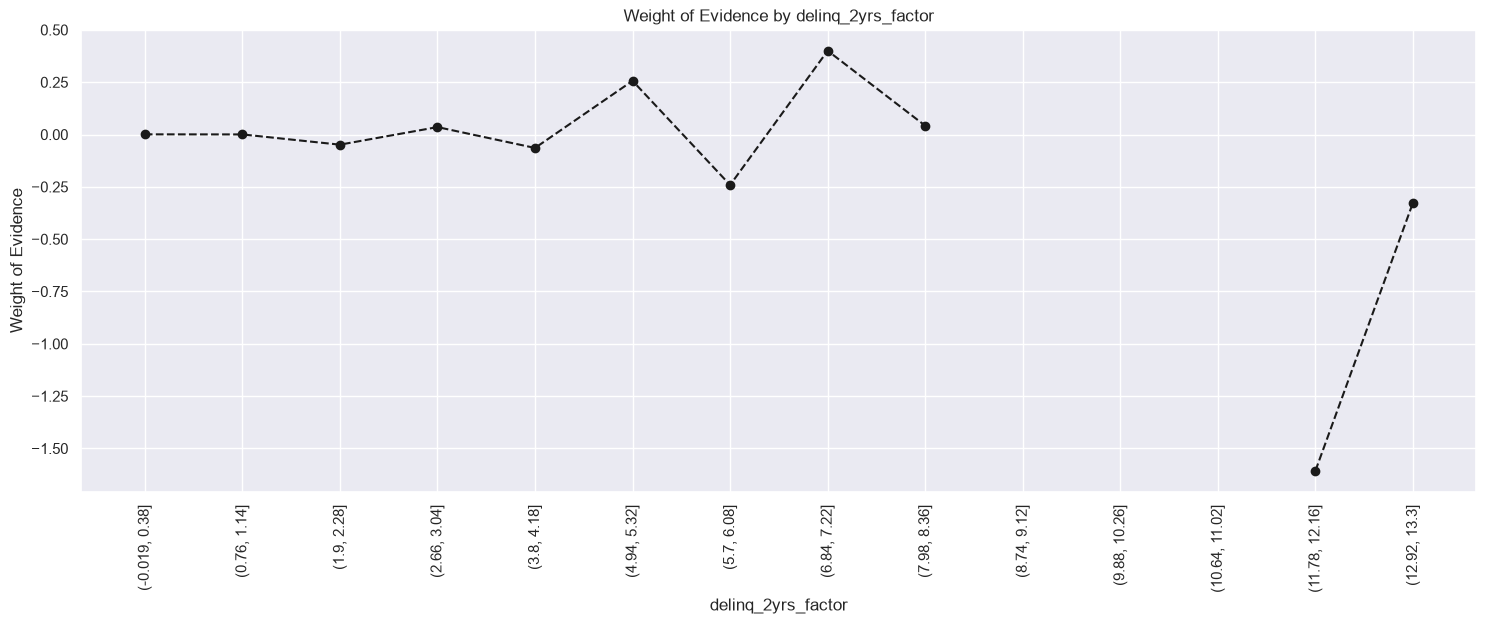

In [824]:
# ------------------------------------------------------------------------------------
# VARIABLE: delinq_2yrs
# ------------------------------------------------------------------------------------

# This variable is categorical, split in 50 categories
df_inputs_prepr['delinq_2yrs_factor'] = pd.cut(df_inputs_prepr.delinq_2yrs, 50)

column_checked = "delinq_2yrs_factor"

delinq_2yrs_factor_WoE_IV = WOE_AND_IV_updated(
    df_inputs=df_inputs,
    input_col_name=column_checked,
    df_output=df_output,
    discrete=False
)

print(delinq_2yrs_factor_WoE_IV)

# Plot
delinq_2yrs_factor_WoE_plot = plot_by_woe(
    delinq_2yrs_factor_WoE_IV, 90
)

In [825]:
df_inputs_prepr['delinq_2yrs:0'] = np.where((df_inputs_prepr['delinq_2yrs'] == 0), 1, 0)
df_inputs_prepr['delinq_2yrs:1-3'] = np.where((df_inputs_prepr['delinq_2yrs'] >= 1) & (df_inputs_prepr['delinq_2yrs'] <= 3), 1, 0)
df_inputs_prepr['delinq_2yrs:>=4'] = np.where((df_inputs_prepr['delinq_2yrs'] >= 9), 1, 0)

c:\Users\jluyandosanchez\Documents\ANACONDA\envs\credit_risk_course\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


   inq_last_6mths_factor  n_obs  prop_nondefaulted  prop_n_obs  \
0         (-0.024, 0.48]  48295           0.911709    0.517870   
1           (0.96, 1.44]  25985           0.884395    0.278639   
2            (1.92, 2.4]  11611           0.863492    0.124505   
3           (2.88, 3.36]   5086           0.848014    0.054537   
4           (3.84, 4.32]   1431           0.843466    0.015345   
5            (4.8, 5.28]    551           0.847550    0.005908   
6           (5.76, 6.24]    211           0.772512    0.002263   
7            (6.72, 7.2]     36           0.527778    0.000386   
8           (7.68, 8.16]     21           0.523810    0.000225   
9           (8.64, 9.12]      7           0.428571    0.000075   
10          (9.6, 10.08]      7           0.857143    0.000075   
11        (10.56, 11.04]      7           1.000000    0.000075   
12         (11.52, 12.0]      3           1.000000    0.000032   
13        (12.96, 13.44]      1           0.000000    0.000011   
14        

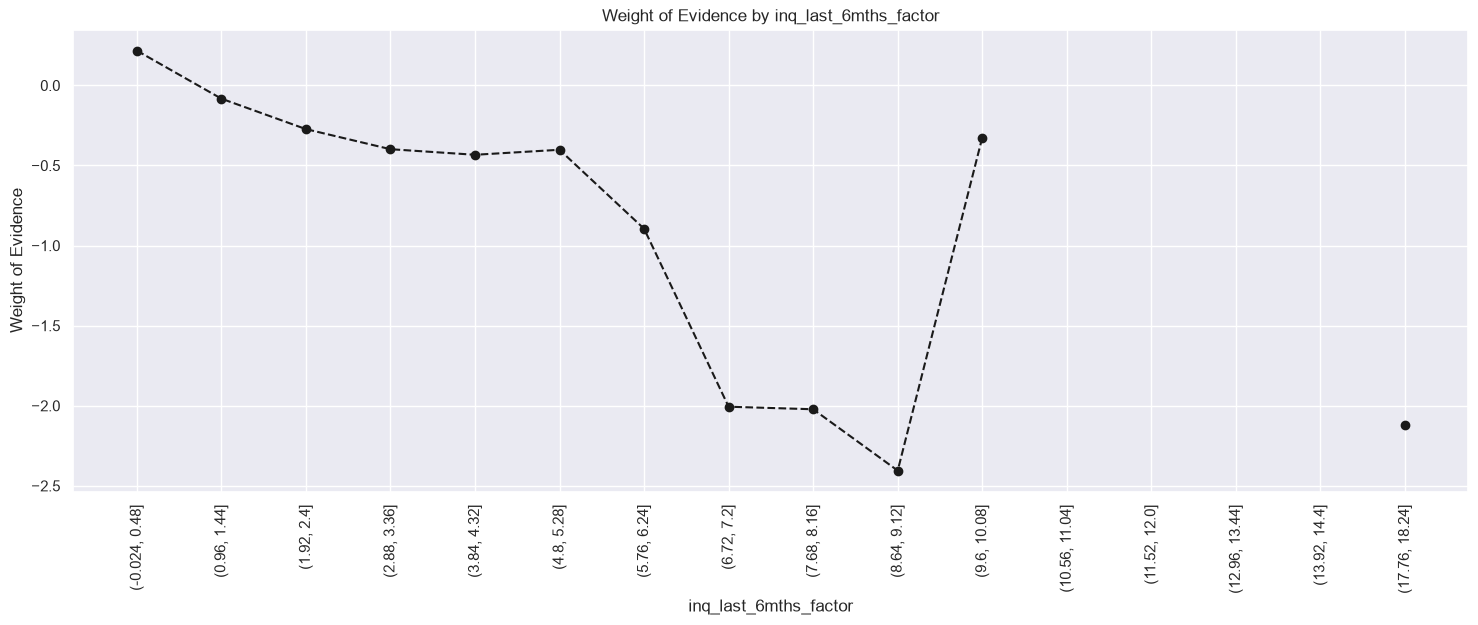

In [826]:
# ------------------------------------------------------------------------------------
# VARIABLE: inq_last_6mths
# ------------------------------------------------------------------------------------

# This variable is categorical, split in 50 categories
df_inputs_prepr['inq_last_6mths_factor'] = pd.cut(df_inputs_prepr.inq_last_6mths, 50)

column_checked = "inq_last_6mths_factor"

inq_last_6mths_factor_WoE_IV = WOE_AND_IV_updated(
    df_inputs=df_inputs,
    input_col_name=column_checked,
    df_output=df_output,
    discrete=False
)

print(inq_last_6mths_factor_WoE_IV)

# Plot
inq_last_6mths_factor_WoE_plot = plot_by_woe(
    inq_last_6mths_factor_WoE_IV, 90
)

In [827]:
df_inputs_prepr['inq_last_6mths:0'] = np.where((df_inputs_prepr['inq_last_6mths'] == 0), 1, 0)
df_inputs_prepr['inq_last_6mths:1-2'] = np.where((df_inputs_prepr['inq_last_6mths'] >= 1) & (df_inputs_prepr['inq_last_6mths'] <= 2), 1, 0)
df_inputs_prepr['inq_last_6mths:3-6'] = np.where((df_inputs_prepr['inq_last_6mths'] >= 3) & (df_inputs_prepr['inq_last_6mths'] <= 6), 1, 0)
df_inputs_prepr['inq_last_6mths:>6'] = np.where((df_inputs_prepr['inq_last_6mths'] > 6), 1, 0)

   open_acc_factor  n_obs  prop_nondefaulted  prop_n_obs  n_nondefaulted  \
0   (-0.061, 1.22]     39           0.897436    0.000418            35.0   
1     (1.22, 2.44]    334           0.838323    0.003582           280.0   
2     (2.44, 3.66]   1122           0.855615    0.012031           960.0   
3     (3.66, 4.88]   2560           0.894141    0.027451          2289.0   
4      (4.88, 6.1]  10619           0.891986    0.113868          9472.0   
5      (6.1, 7.32]   7433           0.888874    0.079704          6607.0   
6     (7.32, 8.54]   8314           0.894756    0.089151          7439.0   
7     (8.54, 9.76]   8768           0.890283    0.094020          7806.0   
8    (9.76, 10.98]   8576           0.891441    0.091961          7645.0   
9    (10.98, 12.2]  14626           0.892520    0.156835         13054.0   
10   (12.2, 13.42]   5914           0.895164    0.063416          5294.0   
11  (13.42, 14.64]   4960           0.897984    0.053186          4454.0   
12  (14.64, 

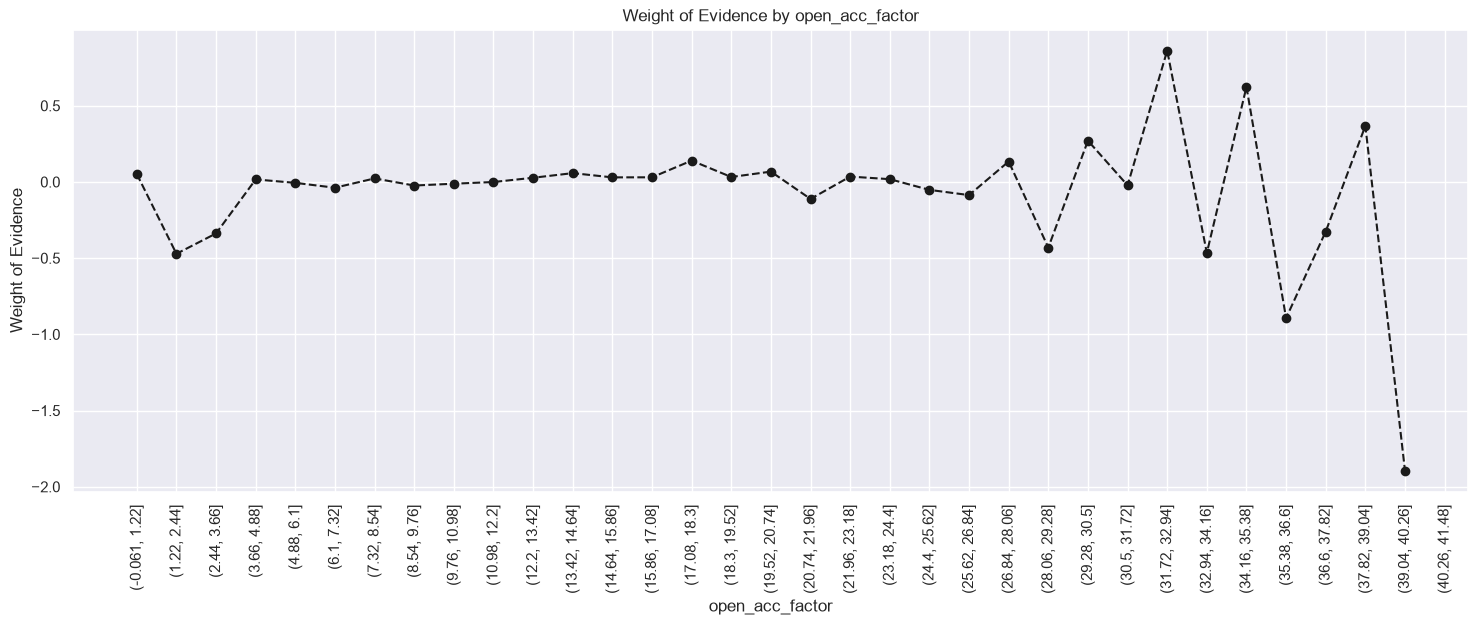

In [828]:
# ------------------------------------------------------------------------------------
# VARIABLE: open_acc
# ------------------------------------------------------------------------------------

# This variable is categorical, split in 50 categories
df_inputs_prepr['open_acc_factor'] = pd.cut(df_inputs_prepr.open_acc, 50)

column_checked = "open_acc_factor"

open_acc_factor_WoE_IV = WOE_AND_IV_updated(
    df_inputs=df_inputs,
    input_col_name=column_checked,
    df_output=df_output,
    discrete=False
)

print(open_acc_factor_WoE_IV)

# Plot
open_acc_factor_WoE_plot = plot_by_woe(
    open_acc_factor_WoE_IV, 90
)

In [829]:
df_inputs_prepr['open_acc:0'] = np.where((df_inputs_prepr['open_acc'] == 0), 1, 0)
df_inputs_prepr['open_acc:1-3'] = np.where((df_inputs_prepr['open_acc'] >= 1) & (df_inputs_prepr['open_acc'] <= 3), 1, 0)
df_inputs_prepr['open_acc:4-12'] = np.where((df_inputs_prepr['open_acc'] >= 4) & (df_inputs_prepr['open_acc'] <= 12), 1, 0)
df_inputs_prepr['open_acc:13-17'] = np.where((df_inputs_prepr['open_acc'] >= 13) & (df_inputs_prepr['open_acc'] <= 17), 1, 0)
df_inputs_prepr['open_acc:18-22'] = np.where((df_inputs_prepr['open_acc'] >= 18) & (df_inputs_prepr['open_acc'] <= 22), 1, 0)
df_inputs_prepr['open_acc:23-25'] = np.where((df_inputs_prepr['open_acc'] >= 23) & (df_inputs_prepr['open_acc'] <= 25), 1, 0)
df_inputs_prepr['open_acc:26-30'] = np.where((df_inputs_prepr['open_acc'] >= 26) & (df_inputs_prepr['open_acc'] <= 30), 1, 0)
df_inputs_prepr['open_acc:>=31'] = np.where((df_inputs_prepr['open_acc'] >= 31), 1, 0)

    pub_rec_factor  n_obs  prop_nondefaulted  prop_n_obs  n_nondefaulted  \
0   (-0.049, 0.98]  80923           0.891020    0.867742         72104.0   
1     (0.98, 1.96]  10670           0.902718    0.114415          9632.0   
2     (1.96, 2.94]   1097           0.908842    0.011763           997.0   
3     (2.94, 3.92]    331           0.903323    0.003549           299.0   
4      (3.92, 4.9]    112           0.866071    0.001201            97.0   
5      (4.9, 5.88]     73           0.904110    0.000783            66.0   
6     (5.88, 6.86]     19           0.894737    0.000204            17.0   
7     (6.86, 7.84]     14           0.785714    0.000150            11.0   
8     (7.84, 8.82]      5           0.800000    0.000054             4.0   
9      (8.82, 9.8]      2           1.000000    0.000021             2.0   
10    (9.8, 10.78]      3           1.000000    0.000032             3.0   
11  (10.78, 11.76]      5           1.000000    0.000054             5.0   
12  (11.76, 

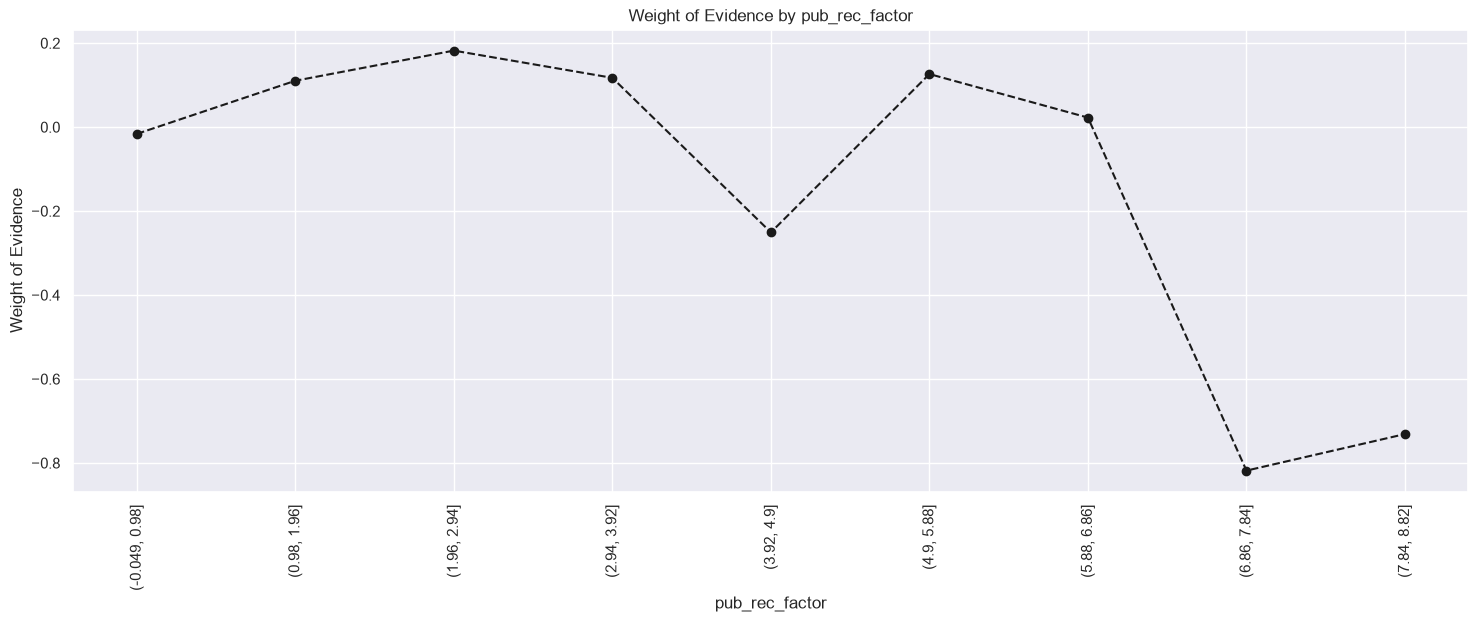

In [830]:
# ------------------------------------------------------------------------------------
# VARIABLE: pub_rec
# ------------------------------------------------------------------------------------

# This variable is categorical, split in 50 categories
df_inputs_prepr['pub_rec_factor'] = pd.cut(df_inputs_prepr.pub_rec, 50)

column_checked = "pub_rec_factor"

pub_rec_factor_WoE_IV = WOE_AND_IV_updated(
    df_inputs=df_inputs,
    input_col_name=column_checked,
    df_output=df_output,
    discrete=False
)

print(pub_rec_factor_WoE_IV)

# Plot
pub_rec_factor_WoE_plot = plot_by_woe(
    pub_rec_factor_WoE_IV, 90
)

In [831]:
df_inputs_prepr['pub_rec:0-2'] = np.where((df_inputs_prepr['pub_rec'] >= 0) & (df_inputs_prepr['pub_rec'] <= 2), 1, 0)
df_inputs_prepr['pub_rec:3-4'] = np.where((df_inputs_prepr['pub_rec'] >= 3) & (df_inputs_prepr['pub_rec'] <= 4), 1, 0)
df_inputs_prepr['pub_rec:>=5'] = np.where((df_inputs_prepr['pub_rec'] >= 5), 1, 0)

   total_acc_factor  n_obs  prop_nondefaulted  prop_n_obs  n_nondefaulted  \
0    (-0.156, 3.12]    125           0.776000    0.001340            97.0   
1      (3.12, 6.24]   1499           0.852568    0.016074          1278.0   
2      (6.24, 9.36]   3715           0.872678    0.039836          3242.0   
3     (9.36, 12.48]   6288           0.877067    0.067427          5515.0   
4     (12.48, 15.6]   8289           0.890578    0.088883          7382.0   
5     (15.6, 18.72]   9843           0.892309    0.105547          8783.0   
6    (18.72, 21.84]  10270           0.895521    0.110126          9197.0   
7    (21.84, 24.96]   9971           0.893792    0.106920          8912.0   
8    (24.96, 28.08]  11873           0.894382    0.127315         10619.0   
9     (28.08, 31.2]   7289           0.894224    0.078160          6518.0   
10    (31.2, 34.32]   6151           0.904081    0.065958          5561.0   
11   (34.32, 37.44]   4745           0.907271    0.050881          4305.0   

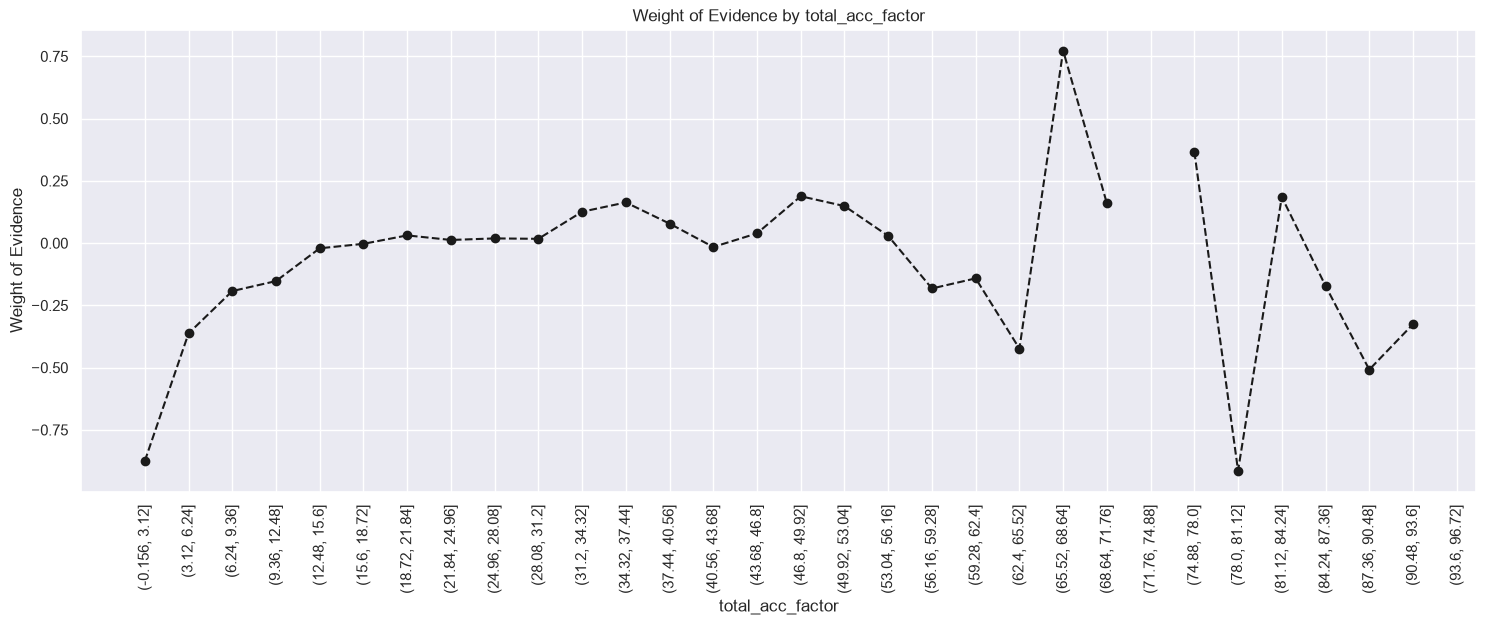

In [832]:
# ------------------------------------------------------------------------------------
# VARIABLE: total_acc
# ------------------------------------------------------------------------------------

# This variable is categorical, split in 50 categories
df_inputs_prepr['total_acc_factor'] = pd.cut(df_inputs_prepr.total_acc, 50)

column_checked = "total_acc_factor"

total_acc_factor_WoE_IV = WOE_AND_IV_updated(
    df_inputs=df_inputs,
    input_col_name=column_checked,
    df_output=df_output,
    discrete=False
)

print(total_acc_factor_WoE_IV)

# Plot
total_acc_factor_WoE_plot = plot_by_woe(
    total_acc_factor_WoE_IV, 90
)

In [833]:
df_inputs_prepr['total_acc:<=27'] = np.where((df_inputs_prepr['total_acc'] <= 27), 1, 0)
df_inputs_prepr['total_acc:28-51'] = np.where((df_inputs_prepr['total_acc'] >= 28) & (df_inputs_prepr['total_acc'] <= 51), 1, 0)
df_inputs_prepr['total_acc:>=52'] = np.where((df_inputs_prepr['total_acc'] >= 52), 1, 0)

  acc_now_delinq_factor  n_obs  prop_nondefaulted  prop_n_obs  n_nondefaulted  \
0        (-0.003, 0.06]  92871           0.892690    0.995861         82905.0   
1          (0.96, 1.02]    360           0.872222    0.003860           314.0   
2          (1.98, 2.04]     22           0.818182    0.000236            18.0   
3           (2.94, 3.0]      4           0.750000    0.000043             3.0   

   n_defaulted  prop_n_nondefaulted  prop_n_defaulted       WoE  \
0       9966.0             0.995975          0.994909  0.001072   
1         46.0             0.003772          0.004592 -0.196693   
2          4.0             0.000216          0.000399 -0.613367   
3          1.0             0.000036          0.000100 -1.018832   

   diff_prop_nondefaulted  diff_WoE       IV  
0                     NaN       NaN  0.00034  
1                0.020468  0.197764  0.00034  
2                0.054040  0.416674  0.00034  
3                0.068182  0.405465  0.00034  


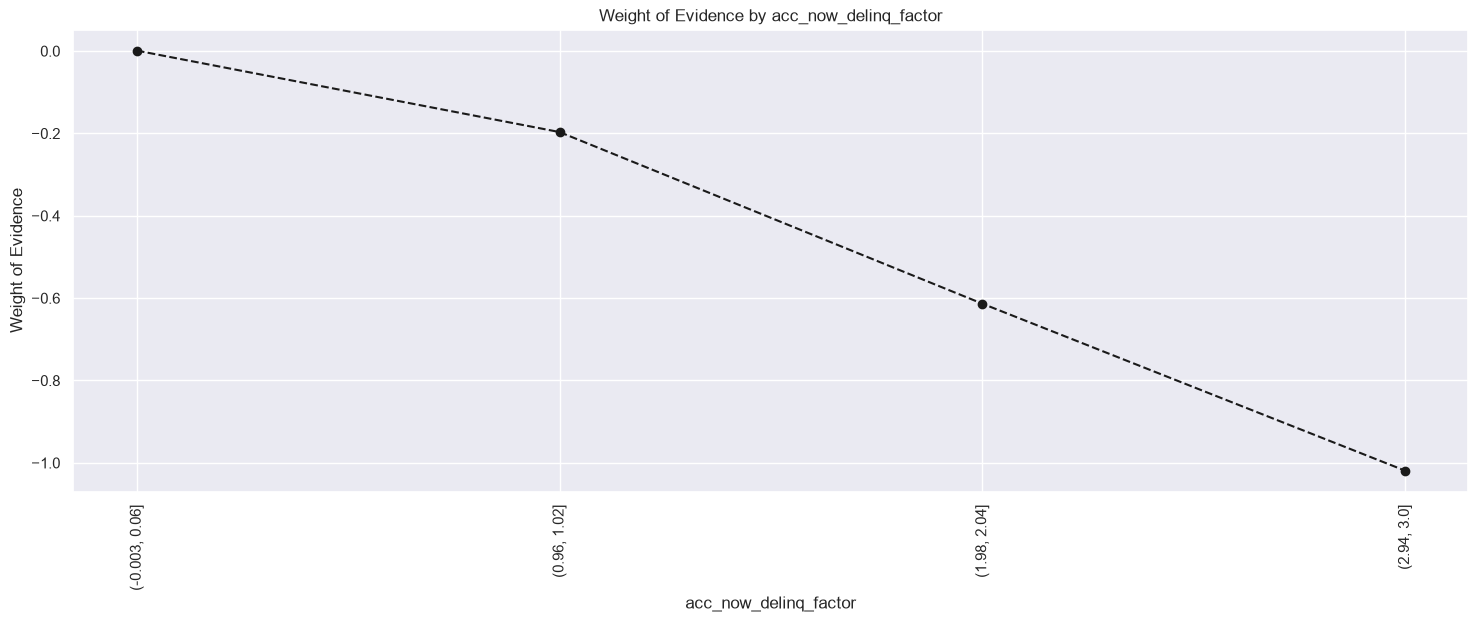

In [834]:
# ------------------------------------------------------------------------------------
# VARIABLE: acc_now_delinq
# ------------------------------------------------------------------------------------

# This variable is categorical, split in 50 categories
df_inputs_prepr['acc_now_delinq_factor'] = pd.cut(df_inputs_prepr.acc_now_delinq, 50)

column_checked = "acc_now_delinq_factor"

acc_now_delinq_factor_WoE_IV = WOE_AND_IV_updated(
    df_inputs=df_inputs,
    input_col_name=column_checked,
    df_output=df_output,
    discrete=False
)

print(acc_now_delinq_factor_WoE_IV)

# Plot
acc_now_delinq_factor_WoE_plot = plot_by_woe(
    acc_now_delinq_factor_WoE_IV, 90
)

In [835]:
df_inputs_prepr['acc_now_delinq:0'] = np.where((df_inputs_prepr['acc_now_delinq'] == 0), 1, 0)
df_inputs_prepr['acc_now_delinq:>=1'] = np.where((df_inputs_prepr['acc_now_delinq'] >= 1), 1, 0)

     total_rev_hi_lim_factor  n_obs  prop_nondefaulted  prop_n_obs  \
0      (-2013.133, 40262.66]  75495           0.884920    0.809537   
1       (40262.66, 80525.32]  14245           0.920604    0.152750   
2      (80525.32, 120787.98]   2348           0.939523    0.025178   
3     (120787.98, 161050.64]    635           0.954331    0.006809   
4      (161050.64, 201313.3]    235           0.957447    0.002520   
5      (201313.3, 241575.96]    129           0.953488    0.001383   
6     (241575.96, 281838.62]     63           0.904762    0.000676   
7     (281838.62, 322101.28]     40           0.950000    0.000429   
8     (322101.28, 362363.94]     21           1.000000    0.000225   
9      (362363.94, 402626.6]     13           0.846154    0.000139   
10     (402626.6, 442889.26]      6           1.000000    0.000064   
11    (442889.26, 483151.92]      6           0.833333    0.000064   
12    (483151.92, 523414.58]      2           1.000000    0.000021   
13    (523414.58, 56

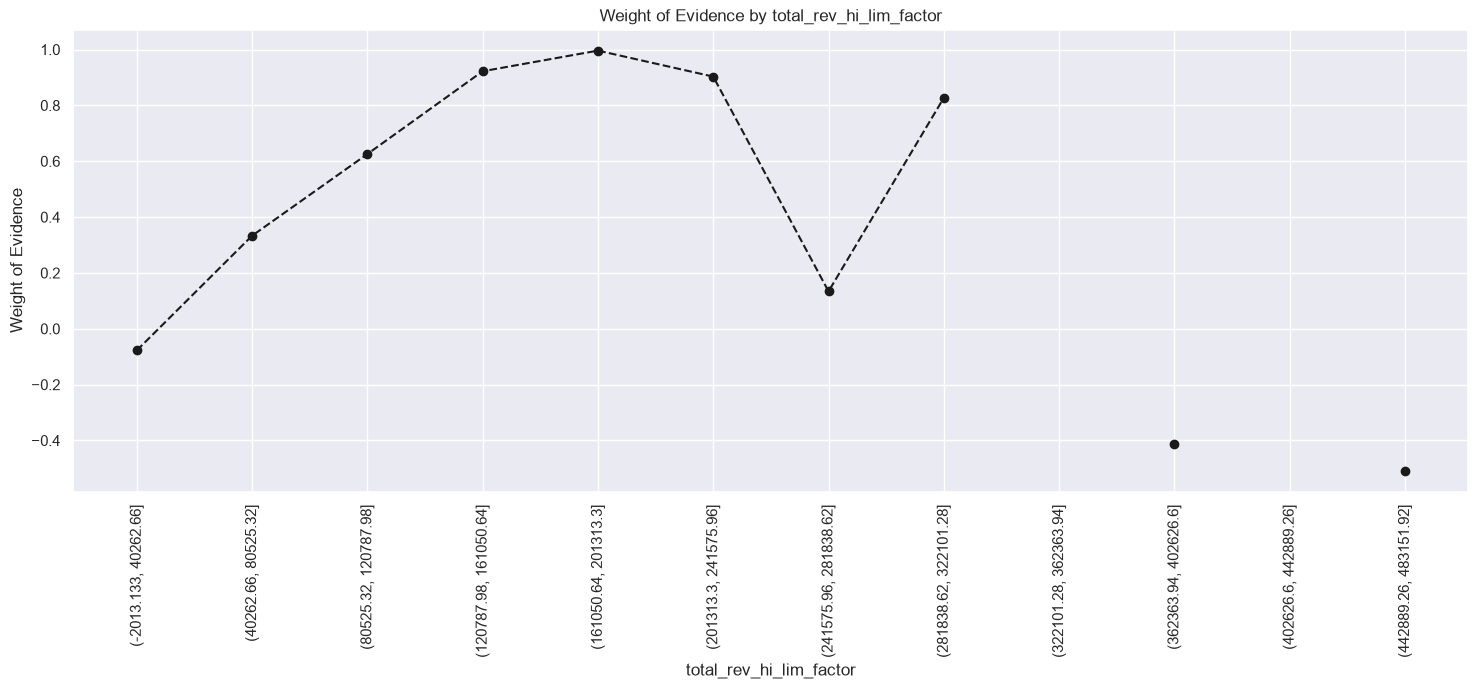

In [836]:
# ------------------------------------------------------------------------------------
# VARIABLE: total_rev_hi_lim
# ------------------------------------------------------------------------------------

# This variable is categorical, split in 50 categories
df_inputs_prepr['total_rev_hi_lim_factor'] = pd.cut(df_inputs_prepr.total_rev_hi_lim, 50)

column_checked = "total_rev_hi_lim_factor"

total_rev_hi_lim_factor_WoE_IV = WOE_AND_IV_updated(
    df_inputs=df_inputs,
    input_col_name=column_checked,
    df_output=df_output,
    discrete=False
)

print(total_rev_hi_lim_factor_WoE_IV)

# Plot
total_rev_hi_lim_factor_WoE_plot = plot_by_woe(
    total_rev_hi_lim_factor_WoE_IV,
    90
)

In [837]:
df_inputs_prepr['total_rev_hi_lim:<=5K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] <= 5000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:5K-10K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 5000) & (df_inputs_prepr['total_rev_hi_lim'] <= 10000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:10K-20K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 10000) & (df_inputs_prepr['total_rev_hi_lim'] <= 20000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:20K-30K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 20000) & (df_inputs_prepr['total_rev_hi_lim'] <= 30000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:30K-40K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 30000) & (df_inputs_prepr['total_rev_hi_lim'] <= 40000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:40K-55K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 40000) & (df_inputs_prepr['total_rev_hi_lim'] <= 55000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:55K-95K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 55000) & (df_inputs_prepr['total_rev_hi_lim'] <= 95000), 1, 0)
df_inputs_prepr['total_rev_hi_lim:>95K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 95000), 1, 0)

C:\Users\jluyandosanchez\AppData\Local\Temp\ipykernel_23980\1572597749.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['total_rev_hi_lim:20K-30K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 20000) & (df_inputs_prepr['total_rev_hi_lim'] <= 30000), 1, 0)
C:\Users\jluyandosanchez\AppData\Local\Temp\ipykernel_23980\1572597749.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['total_rev_hi_lim:30K-40K'] = np.where((df_inputs_prepr['total_rev_hi_lim'] > 30000) & (df_inputs_prepr['total_rev_

In [838]:
# UPDATED LIST FOR OUR MODEL USAGE =======>

# DISCRETE ==>
# ['grade:A', 'grade:B', 'grade:C', 'grade:D', 'grade:E', 'grade:F', 'grade:G']
# ['home_ownership:RENT_OTHER_NONE_ANY', 'home_ownership:MORTGAGE', 'home_ownership:OWN']
# ['addr_state:NE_IA_NV_FL_HI_AL', 'addr_state:NM_VA', 'addr_state:OK_TN_MO_LA_MD_NC', 'addr_state:UT_KY_AZ_NJ', 'addr_state:AR_MI_PA_OH_MN', 'addr_state:RI_MA_DE_SD_IN', 'addr_state:GA_WA_OR', 'addr_state:WI_MT', 'addr_state:IL_CT', 'addr_state:KS_SC_CO_VT_AK_MS', 'addr_state:WV_NH_WY_DC_ME_ID']
# ['verification_status:Verified', 'verification_status:Source Verified', 'Not Verified]
# ['purpose:educ__sm_b__wedd__ren_en__mov__house', 'purpose:oth__med__vacation', 'purpose:major_purch__car__home_impr']
# ['initial_list_status:f', 'initial_list_status:w']

# CONTINOUS ==>
# ['term:36', 'term:60']
# ['emp_length:0', 'emp_length:1', 'emp_length:2-4', 'emp_length:5-6', 'emp_length:7-9', 'emp_length:10']
# ['mths_since_issue_d:<38', 'mths_since_issue_d:38-39', 'mths_since_issue_d:40-41', 'mths_since_issue_d:42-48', 'mths_since_issue_d:49-52', 'mths_since_issue_d:53-64', 'mths_since_issue_d:65-84', 'mths_since_issue_d:>84']
# ['int_rate:<9.548', 'int_rate:9.548-12.025', 'int_rate:12.025-15.74', 'int_rate:15.74-20.281', 'int_rate:>20.281']
# ['mths_since_earliest_cr_line:<140', 'mths_since_earliest_cr_line:141-164', 'mths_since_earliest_cr_line:165-247', 'mths_since_earliest_cr_line:248-270', 'mths_since_earliest_cr_line:271-352', 'mths_since_earliest_cr_line:>352']
# ['delinq_2yrs:0', 'delinq_2yrs:1-3', 'delinq_2yrs:>=4']
# ['inq_last_6mths:0', 'inq_last_6mths:1-2', 'inq_last_6mths:3-6', 'inq_last_6mths:>6']
# ['open_acc:0', 'open_acc:1-3', 'open_acc:4-12', 'open_acc:13-17', 'open_acc:18-22', 'open_acc:23-25', 'open_acc:26-30', 'open_acc:>=31']
# ['pub_rec:0-2', 'pub_rec:3-4', 'pub_rec:>=5']
# ['total_acc:<=27', 'total_acc:28-51', 'total_acc:>=52']
# ['acc_now_delinq:0', 'acc_now_delinq:>=1']
# ['total_rev_hi_lim:<=5K', 'total_rev_hi_lim:5K-10K', 'total_rev_hi_lim:10K-20K', 'total_rev_hi_lim:20K-30K', 'total_rev_hi_lim:30K-40K', 'total_rev_hi_lim:40K-55K', 'total_rev_hi_lim:55K-95K', 'total_rev_hi_lim:>95K']

# UPDATED LIST OF REFERENCE CATEGORIES ========>

# DISCRETE ==>
# 'grade:G'
# 'home_ownership:RENT_OTHER_NONE_ANY'
# 'addr_state:NE_IA_NV_FL_HI_AL'
# 'verification_status:Verified'
# 'purpose:educ__sm_b__wedd__ren_en__mov__house'
# 'initial_list_status:f'

# CONTINOUS ==>
# 'term:60'
# 'emp_length:0'
# 'mths_since_issue_d:>84'
# 'int_rate:>20.281'
# 'mths_since_earliest_cr_line:<140'
# 'delinq_2yrs:>=4'
# 'inq_last_6mths:>6'
# 'open_acc:0'
# 'pub_rec:0-2'
# 'total_acc:<=27'
# 'acc_now_delinq:0'
# 'total_rev_hi_lim:<=5K'

What happens when sometimes, some intervals contain a large number of data when we split the factors into 50?

We do a bigger and more detailes split

C:\Users\jluyandosanchez\AppData\Local\Temp\ipykernel_23980\2617838049.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['annual_inc_factor'] = pd.cut(df_inputs_prepr.annual_inc, 50)


         annual_inc_factor  n_obs  prop_nondefaulted  prop_n_obs  \
0      (-2695.2, 154704.0]  89203           0.890901    0.956529   
1     (154704.0, 304608.0]   3626           0.928296    0.038882   
2     (304608.0, 454512.0]    282           0.932624    0.003024   
3     (454512.0, 604416.0]     86           0.965116    0.000922   
4     (604416.0, 754320.0]     23           0.956522    0.000247   
5     (754320.0, 904224.0]     18           0.944444    0.000193   
6    (904224.0, 1054128.0]      7           1.000000    0.000075   
7   (1054128.0, 1204032.0]      6           1.000000    0.000064   
8   (1204032.0, 1353936.0]      2           0.500000    0.000021   
9   (1353936.0, 1503840.0]      2           1.000000    0.000021   
10  (7350096.0, 7500000.0]      2           1.000000    0.000021   

    n_nondefaulted  n_defaulted  prop_n_nondefaulted  prop_n_defaulted  \
0          79471.0       9732.0             0.954721          0.971548   
1           3366.0        260.0    

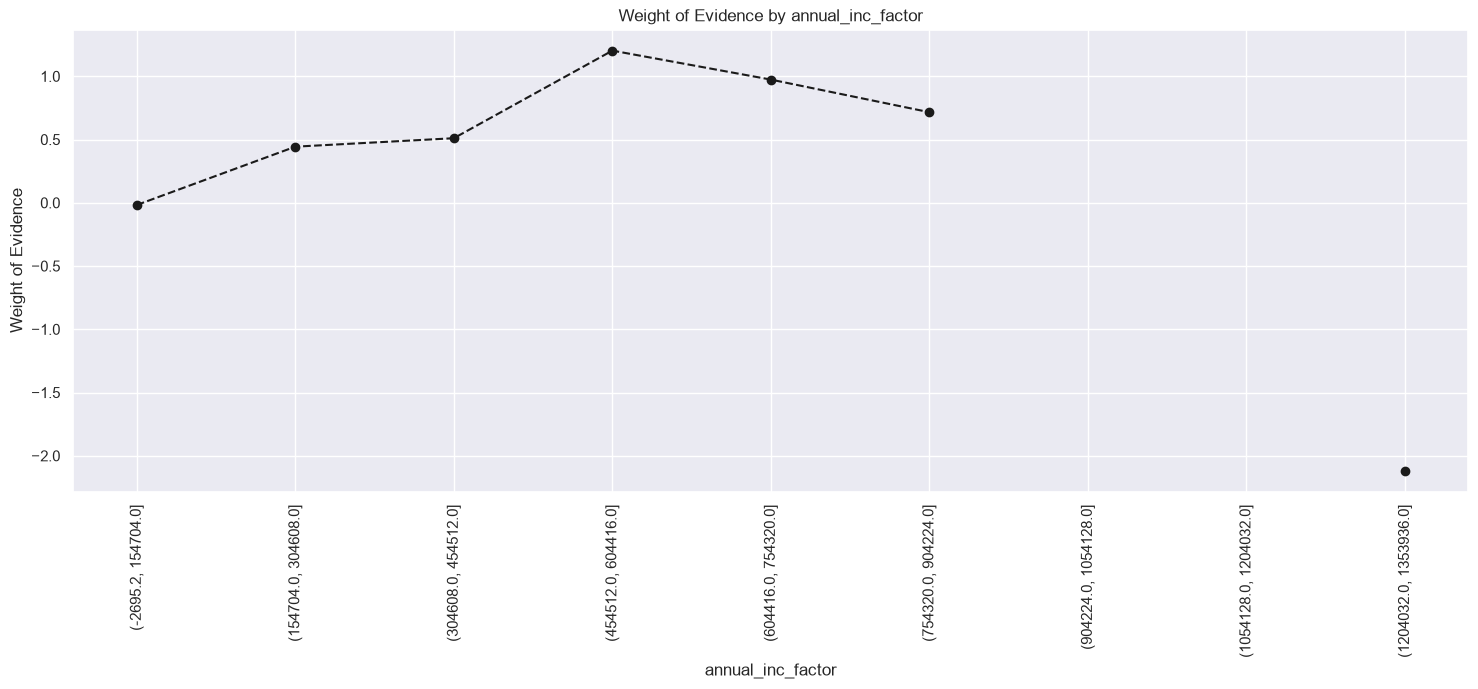

In [839]:
# ------------------------------------------------------------------------------------
# VARIABLE: annual_inc_factor --> Check 1
# ------------------------------------------------------------------------------------

# This variable is categorical, split in 50 categories
df_inputs_prepr['annual_inc_factor'] = pd.cut(df_inputs_prepr.annual_inc, 50)

column_checked = "annual_inc_factor"

annual_inc_factor_WoE_IV = WOE_AND_IV_updated(
    df_inputs=df_inputs,
    input_col_name=column_checked,
    df_output=df_output,
    discrete=False
)

print(annual_inc_factor_WoE_IV)

# Plot
annual_inc_factor_WoE_plot = plot_by_woe(
    annual_inc_factor_WoE_IV, 90
)

# We can see that (-5243.882, 144693.64]  contains 94% of the whole data checking prop_n_obs
# That's why we will split the data into more factors
# Note that the number of observations become lower and lower as we move to categories with higher income

         annual_inc_factor  n_obs  prop_nondefaulted  prop_n_obs  \
0       (-2695.2, 79752.0]  62621           0.879992    0.671488   
1      (79752.0, 154704.0]  26582           0.916598    0.285040   
2     (154704.0, 229656.0]   2916           0.928326    0.031268   
3     (229656.0, 304608.0]    710           0.928169    0.007613   
4     (304608.0, 379560.0]    171           0.935673    0.001834   
5     (379560.0, 454512.0]    111           0.927928    0.001190   
6     (454512.0, 529464.0]     53           0.962264    0.000568   
7     (529464.0, 604416.0]     33           0.969697    0.000354   
8     (604416.0, 679368.0]     10           1.000000    0.000107   
9     (679368.0, 754320.0]     13           0.923077    0.000139   
10    (754320.0, 829272.0]      5           1.000000    0.000054   
11    (829272.0, 904224.0]     13           0.923077    0.000139   
12    (904224.0, 979176.0]      3           1.000000    0.000032   
13   (979176.0, 1054128.0]      4           1.00

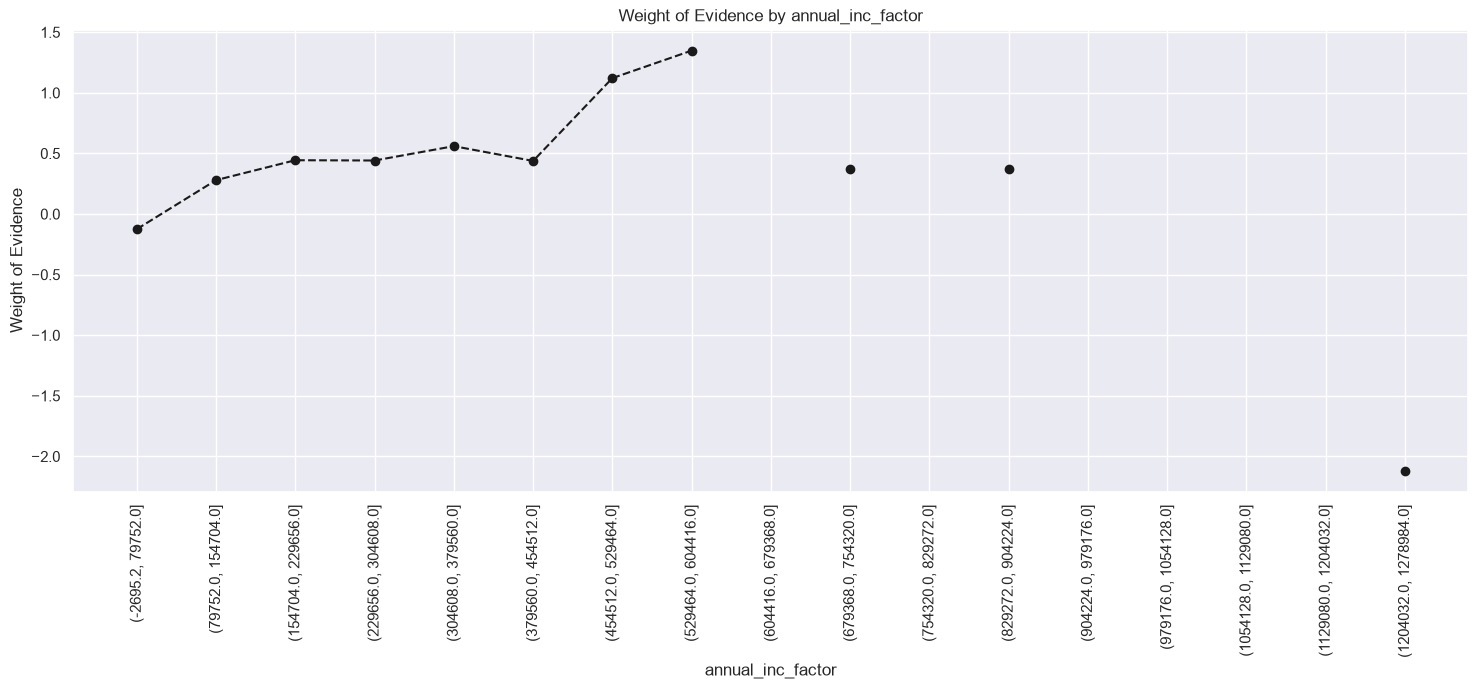

In [840]:
# ------------------------------------------------------------------------------------
# VARIABLE: annual_inc_factor --> Check 2
# ------------------------------------------------------------------------------------

# This variable is categorical, split in 50 categories
df_inputs_prepr['annual_inc_factor'] = pd.cut(df_inputs_prepr.annual_inc, 100)

column_checked = "annual_inc_factor"

annual_inc_factor_WoE_IV = WOE_AND_IV_updated(
    df_inputs=df_inputs,
    input_col_name=column_checked,
    df_output=df_output,
    discrete=False
)

print(annual_inc_factor_WoE_IV)

# Plot
annual_inc_factor_WoE_plot = plot_by_woe(
    annual_inc_factor_WoE_IV, 90
)

# We will assume thtat the threshold of highing a high income is 144693.64, so anyone above this line will fall into one factor
# This will allow us to focus on the categories below it


       annual_inc_factor  n_obs  prop_nondefaulted  prop_n_obs  \
0       (4664.8, 7504.0]     10           1.000000    0.000114   
1      (7504.0, 10208.0]     84           0.761905    0.000958   
2     (10208.0, 12912.0]    123           0.780488    0.001403   
3     (12912.0, 15616.0]    304           0.851974    0.003467   
4     (15616.0, 18320.0]    383           0.830287    0.004368   
5     (18320.0, 21024.0]    733           0.843111    0.008359   
6     (21024.0, 23728.0]    704           0.849432    0.008028   
7     (23728.0, 26432.0]   1785           0.862185    0.020356   
8     (26432.0, 29136.0]   1355           0.854613    0.015452   
9     (29136.0, 31840.0]   2292           0.858639    0.026137   
10    (31840.0, 34544.0]   2130           0.857746    0.024290   
11    (34544.0, 37248.0]   3525           0.855319    0.040198   
12    (37248.0, 39952.0]   1926           0.882139    0.021963   
13    (39952.0, 42656.0]   4973           0.870501    0.056710   
14    (426

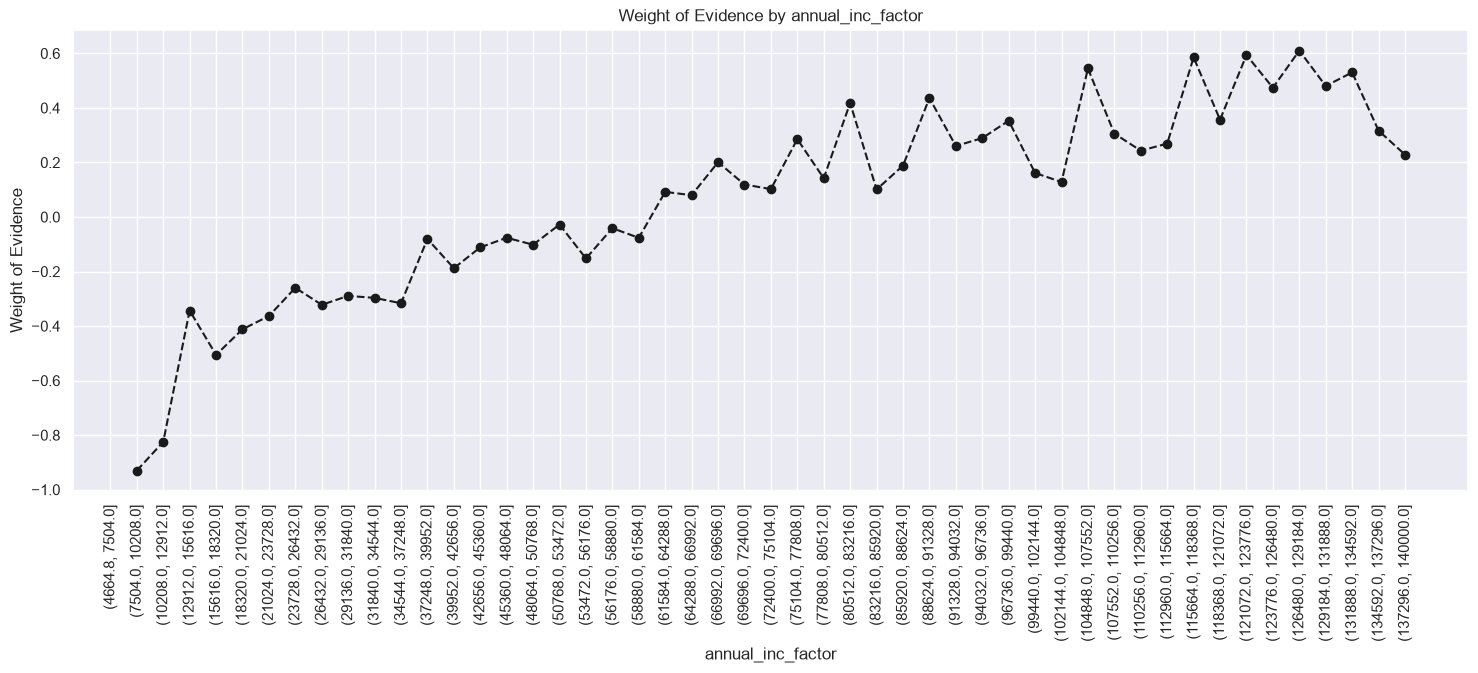

In [841]:
# ------------------------------------------------------------------------------------
# VARIABLE: annual_inc_factor --> Check 3
# ------------------------------------------------------------------------------------

# Get just the specific df_inputs_prepr['annual_inc'] < 140000
df_inputs_prepr_temp = df_inputs_prepr.loc[df_inputs_prepr['annual_inc'] <= 140000, :]

# This variable is categorical, split in 50 categories
df_inputs_prepr_temp['annual_inc_factor'] = pd.cut(df_inputs_prepr_temp['annual_inc'], 50)

column_checked = "annual_inc_factor"

annual_inc_factor_WoE_IV = WOE_AND_IV_updated(
    df_inputs=df_inputs_prepr_temp, # Updated new dataframe
    input_col_name=column_checked,
    df_output=df_output[df_inputs_prepr_temp.index], # Only for the rows whose index match a df_inputs_prepr['annual_inc'] < 140000
    discrete=False
)

print(annual_inc_factor_WoE_IV)

# Plot
annual_inc_factor_WoE_plot = plot_by_woe(
    annual_inc_factor_WoE_IV, 90
)

In [842]:
df_inputs_prepr['annual_inc:<20K'] = np.where((df_inputs_prepr['annual_inc'] <= 20000), 1, 0)
df_inputs_prepr['annual_inc:20K-30K'] = np.where((df_inputs_prepr['annual_inc'] > 20000) & (df_inputs_prepr['annual_inc'] <= 30000), 1, 0)
df_inputs_prepr['annual_inc:30K-40K'] = np.where((df_inputs_prepr['annual_inc'] > 30000) & (df_inputs_prepr['annual_inc'] <= 40000), 1, 0)
df_inputs_prepr['annual_inc:40K-50K'] = np.where((df_inputs_prepr['annual_inc'] > 40000) & (df_inputs_prepr['annual_inc'] <= 50000), 1, 0)
df_inputs_prepr['annual_inc:50K-60K'] = np.where((df_inputs_prepr['annual_inc'] > 50000) & (df_inputs_prepr['annual_inc'] <= 60000), 1, 0)
df_inputs_prepr['annual_inc:60K-70K'] = np.where((df_inputs_prepr['annual_inc'] > 60000) & (df_inputs_prepr['annual_inc'] <= 70000), 1, 0)
df_inputs_prepr['annual_inc:70K-80K'] = np.where((df_inputs_prepr['annual_inc'] > 70000) & (df_inputs_prepr['annual_inc'] <= 80000), 1, 0)
df_inputs_prepr['annual_inc:80K-90K'] = np.where((df_inputs_prepr['annual_inc'] > 80000) & (df_inputs_prepr['annual_inc'] <= 90000), 1, 0)
df_inputs_prepr['annual_inc:90K-100K'] = np.where((df_inputs_prepr['annual_inc'] > 90000) & (df_inputs_prepr['annual_inc'] <= 100000), 1, 0)
df_inputs_prepr['annual_inc:100K-120K'] = np.where((df_inputs_prepr['annual_inc'] > 100000) & (df_inputs_prepr['annual_inc'] <= 120000), 1, 0)
df_inputs_prepr['annual_inc:120K-140K'] = np.where((df_inputs_prepr['annual_inc'] > 120000) & (df_inputs_prepr['annual_inc'] <= 140000), 1, 0)
df_inputs_prepr['annual_inc:>140K'] = np.where((df_inputs_prepr['annual_inc'] > 140000), 1, 0)

C:\Users\jluyandosanchez\AppData\Local\Temp\ipykernel_23980\932304449.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['annual_inc:<20K'] = np.where((df_inputs_prepr['annual_inc'] <= 20000), 1, 0)
C:\Users\jluyandosanchez\AppData\Local\Temp\ipykernel_23980\932304449.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['annual_inc:20K-30K'] = np.where((df_inputs_prepr['annual_inc'] > 20000) & (df_inputs_prepr['annual_inc'] <= 30000), 1, 0)
C:\Users\jluyandosanchez\AppData\Local\Temp\ipykernel_239

For months since last delinquency we have some empty rows

Why don't we create a dummy variable with 1 (non-empty) and 0 (empty)

Or set aside the missing rows

C:\Users\jluyandosanchez\AppData\Local\Temp\ipykernel_23980\3625099119.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_temp['mths_since_last_delinq_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_delinq'], 50)


   mths_since_last_delinq_factor  n_obs  prop_nondefaulted  prop_n_obs  \
0                   (-0.17, 3.4]   1348           0.869436    0.031283   
1                     (3.4, 6.8]   1890           0.883069    0.043861   
2                    (6.8, 10.2]   3373           0.890009    0.078276   
3                   (10.2, 13.6]   2496           0.897035    0.057924   
4                   (13.6, 17.0]   3165           0.886572    0.073449   
5                   (17.0, 20.4]   2282           0.896582    0.052958   
6                   (20.4, 23.8]   2115           0.901182    0.049082   
7                   (23.8, 27.2]   2755           0.897278    0.063934   
8                   (27.2, 30.6]   1929           0.896838    0.044766   
9                   (30.6, 34.0]   2453           0.894415    0.056926   
10                  (34.0, 37.4]   1786           0.906495    0.041447   
11                  (37.4, 40.8]   1765           0.888952    0.040960   
12                  (40.8, 44.2]   227

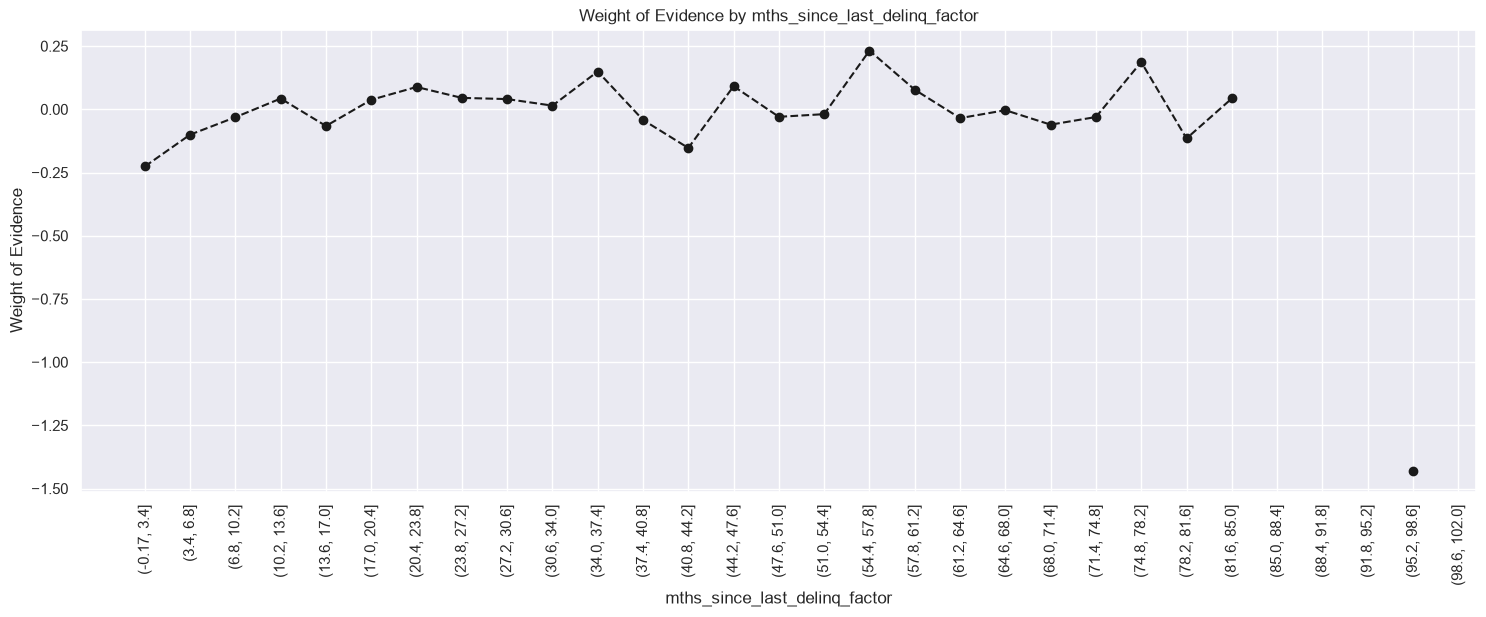

In [843]:
# Work only with non-empty rows
df_inputs_prepr_temp = df_inputs_prepr[pd.notnull(df_inputs_prepr.mths_since_last_delinq)]

# This variable is categorical, split in 50 categories
df_inputs_prepr_temp['mths_since_last_delinq_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_delinq'], 50)

column_checked = "mths_since_last_delinq_factor"

mths_since_last_delinq_factor_WoE_IV = WOE_AND_IV_updated(
    df_inputs=df_inputs_prepr_temp, # Updated new dataframe
    input_col_name=column_checked,
    df_output=df_output[df_inputs_prepr_temp.index], # Only for the rows whose index match a df_inputs_prepr['annual_inc'] < 140000
    discrete=False
)

print(mths_since_last_delinq_factor_WoE_IV)

# Plot
mths_since_last_delinq_factor_WoE_plot = plot_by_woe(
    mths_since_last_delinq_factor_WoE_IV, 90
)

In [844]:
df_inputs_prepr['mths_since_last_delinq:Missing'] = np.where((df_inputs_prepr['mths_since_last_delinq'].isnull()), 1, 0)
df_inputs_prepr['mths_since_last_delinq:0-3'] = np.where((df_inputs_prepr['mths_since_last_delinq'] >= 0) & (df_inputs_prepr['mths_since_last_delinq'] <= 3), 1, 0)
df_inputs_prepr['mths_since_last_delinq:4-30'] = np.where((df_inputs_prepr['mths_since_last_delinq'] >= 4) & (df_inputs_prepr['mths_since_last_delinq'] <= 30), 1, 0)
df_inputs_prepr['mths_since_last_delinq:31-56'] = np.where((df_inputs_prepr['mths_since_last_delinq'] >= 31) & (df_inputs_prepr['mths_since_last_delinq'] <= 56), 1, 0)
df_inputs_prepr['mths_since_last_delinq:>=57'] = np.where((df_inputs_prepr['mths_since_last_delinq'] >= 57), 1, 0)

C:\Users\jluyandosanchez\AppData\Local\Temp\ipykernel_23980\2300411631.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_last_delinq:Missing'] = np.where((df_inputs_prepr['mths_since_last_delinq'].isnull()), 1, 0)
C:\Users\jluyandosanchez\AppData\Local\Temp\ipykernel_23980\2300411631.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_last_delinq:0-3'] = np.where((df_inputs_prepr['mths_since_last_delinq'] >= 0) & (df_inputs_prepr['mths_since_last_delinq'] <= 3), 1, 0)
C:\

In [845]:
# UPDATED LIST FOR OUR MODEL USAGE =======>

# DISCRETE ==>
# ['grade:A', 'grade:B', 'grade:C', 'grade:D', 'grade:E', 'grade:F', 'grade:G']
# ['home_ownership:RENT_OTHER_NONE_ANY', 'home_ownership:MORTGAGE', 'home_ownership:OWN']
# ['addr_state:NE_IA_NV_FL_HI_AL', 'addr_state:NM_VA', 'addr_state:OK_TN_MO_LA_MD_NC', 'addr_state:UT_KY_AZ_NJ', 'addr_state:AR_MI_PA_OH_MN', 'addr_state:RI_MA_DE_SD_IN', 'addr_state:GA_WA_OR', 'addr_state:WI_MT', 'addr_state:IL_CT', 'addr_state:KS_SC_CO_VT_AK_MS', 'addr_state:WV_NH_WY_DC_ME_ID']
# ['verification_status:Verified', 'verification_status:Source Verified', 'Not Verified]
# ['purpose:educ__sm_b__wedd__ren_en__mov__house', 'purpose:oth__med__vacation', 'purpose:major_purch__car__home_impr']
# ['initial_list_status:f', 'initial_list_status:w']

# CONTINOUS ==>
# ['term:36', 'term:60']
# ['emp_length:0', 'emp_length:1', 'emp_length:2-4', 'emp_length:5-6', 'emp_length:7-9', 'emp_length:10']
# ['mths_since_issue_d:<38', 'mths_since_issue_d:38-39', 'mths_since_issue_d:40-41', 'mths_since_issue_d:42-48', 'mths_since_issue_d:49-52', 'mths_since_issue_d:53-64', 'mths_since_issue_d:65-84', 'mths_since_issue_d:>84']
# ['int_rate:<9.548', 'int_rate:9.548-12.025', 'int_rate:12.025-15.74', 'int_rate:15.74-20.281', 'int_rate:>20.281']
# ['mths_since_earliest_cr_line:<140', 'mths_since_earliest_cr_line:141-164', 'mths_since_earliest_cr_line:165-247', 'mths_since_earliest_cr_line:248-270', 'mths_since_earliest_cr_line:271-352', 'mths_since_earliest_cr_line:>352']
# ['delinq_2yrs:0', 'delinq_2yrs:1-3', 'delinq_2yrs:>=4']
# ['inq_last_6mths:0', 'inq_last_6mths:1-2', 'inq_last_6mths:3-6', 'inq_last_6mths:>6']
# ['open_acc:0', 'open_acc:1-3', 'open_acc:4-12', 'open_acc:13-17', 'open_acc:18-22', 'open_acc:23-25', 'open_acc:26-30', 'open_acc:>=31']
# ['pub_rec:0-2', 'pub_rec:3-4', 'pub_rec:>=5']
# ['total_acc:<=27', 'total_acc:28-51', 'total_acc:>=52']
# ['acc_now_delinq:0', 'acc_now_delinq:>=1']
# ['total_rev_hi_lim:<=5K', 'total_rev_hi_lim:5K-10K', 'total_rev_hi_lim:10K-20K', 'total_rev_hi_lim:20K-30K', 'total_rev_hi_lim:30K-40K', 'total_rev_hi_lim:40K-55K', 'total_rev_hi_lim:55K-95K', 'total_rev_hi_lim:>95K']
# ['annual_inc:<20K', 'annual_inc:20K-30K', 'annual_inc:30K-40K', 'annual_inc:40K-50K', 'annual_inc:50K-60K', 'annual_inc:60K-70K', 'annual_inc:70K-80K', 'annual_inc:80K-90K', 'annual_inc:90K-100K', 'annual_inc:100K-120K', 'annual_inc:120K-140K', 'annual_inc:>140K']
# ['mths_since_last_delinq:Missing', 'mths_since_last_delinq:0-3', 'mths_since_last_delinq:4-30', 'mths_since_last_delinq:31-56', 'mths_since_last_delinq:>=57']

# UPDATED LIST OF REFERENCE CATEGORIES ========>

# DISCRETE ==>
# 'grade:G'
# 'home_ownership:RENT_OTHER_NONE_ANY'
# 'addr_state:NE_IA_NV_FL_HI_AL'
# 'verification_status:Verified'
# 'purpose:educ__sm_b__wedd__ren_en__mov__house'
# 'initial_list_status:f'

# CONTINOUS ==>
# 'term:60'
# 'emp_length:0'
# 'mths_since_issue_d:>84'
# 'int_rate:>20.281'
# 'mths_since_earliest_cr_line:<140'
# 'delinq_2yrs:>=4'
# 'inq_last_6mths:>6'
# 'open_acc:0'
# 'pub_rec:0-2'
# 'total_acc:<=27'
# 'acc_now_delinq:0'
# 'total_rev_hi_lim:<=5K'
# 'annual_inc:<20K'
# 'mths_since_last_delinq:>=57'

C:\Users\jluyandosanchez\AppData\Local\Temp\ipykernel_23980\4294670930.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['dti_factor'] = pd.cut(df_inputs_prepr['dti'], 50)


          dti_factor  n_obs  prop_nondefaulted  prop_n_obs  n_nondefaulted  \
0       (-0.04, 0.8]    371           0.889488    0.003978           330.0   
1         (0.8, 1.6]    478           0.899582    0.005126           430.0   
2       (1.6, 2.399]    639           0.902973    0.006852           577.0   
3     (2.399, 3.199]    808           0.914604    0.008664           739.0   
4     (3.199, 3.999]   1047           0.918816    0.011227           962.0   
5     (3.999, 4.799]   1260           0.912698    0.013511          1150.0   
6     (4.799, 5.599]   1527           0.913556    0.016374          1395.0   
7     (5.599, 6.398]   1730           0.906358    0.018551          1568.0   
8     (6.398, 7.198]   1999           0.921961    0.021435          1843.0   
9     (7.198, 7.998]   2227           0.909744    0.023880          2026.0   
10    (7.998, 8.798]   2299           0.911266    0.024652          2095.0   
11    (8.798, 9.598]   2590           0.908494    0.027773      

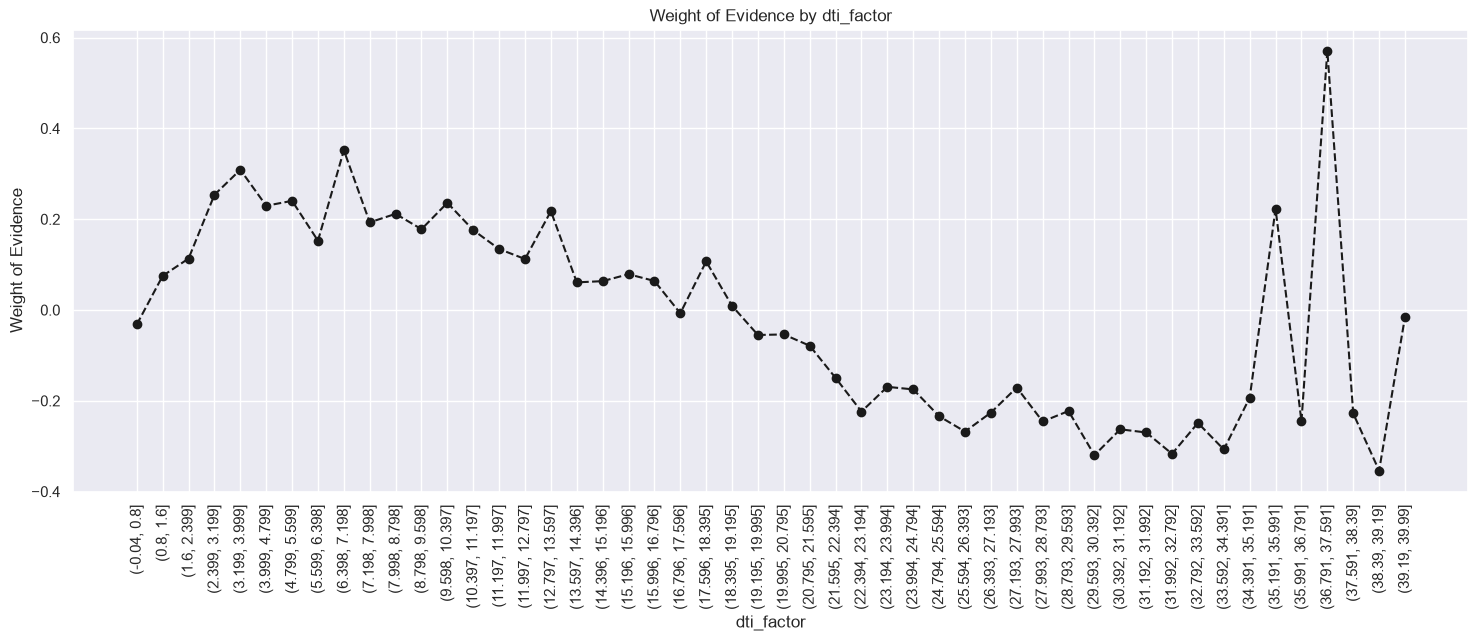

In [846]:
# ------------------------------------------------------------------------------------
# VARIABLE: dti_factor --> Check 1
# ------------------------------------------------------------------------------------

# This variable is categorical, split in 50 categories
df_inputs_prepr['dti_factor'] = pd.cut(df_inputs_prepr['dti'], 50)

column_checked = "dti_factor"

dti_factor_WoE_IV = WOE_AND_IV_updated(
    df_inputs=df_inputs,
    input_col_name=column_checked,
    df_output=df_output,
    discrete=False
)

print(dti_factor_WoE_IV)

# Plot
dti_factor_WoE_plot = plot_by_woe(
    dti_factor_WoE_IV, 90
)

# Similarly to income, initial examination shows that most values are lower than 200.
# Hence, we are going to have one category for more than 35, and we are going to apply our approach to determine
# the categories of everyone with 150k or less.

       dti_factor  n_obs  prop_nondefaulted  prop_n_obs  n_nondefaulted  \
0   (-0.035, 0.7]    328           0.887195    0.003544           291.0   
1      (0.7, 1.4]    393           0.903308    0.004246           355.0   
2      (1.4, 2.1]    536           0.895522    0.005792           480.0   
3      (2.1, 2.8]    607           0.917628    0.006559           557.0   
4      (2.8, 3.5]    811           0.928483    0.008763           753.0   
5      (3.5, 4.2]    970           0.903093    0.010481           876.0   
6      (4.2, 4.9]   1140           0.913158    0.012318          1041.0   
7      (4.9, 5.6]   1370           0.912409    0.014803          1250.0   
8      (5.6, 6.3]   1491           0.906103    0.016111          1351.0   
9      (6.3, 7.0]   1722           0.928571    0.018607          1599.0   
10     (7.0, 7.7]   1846           0.905200    0.019946          1671.0   
11     (7.7, 8.4]   2044           0.910470    0.022086          1861.0   
12     (8.4, 9.1]   2097 

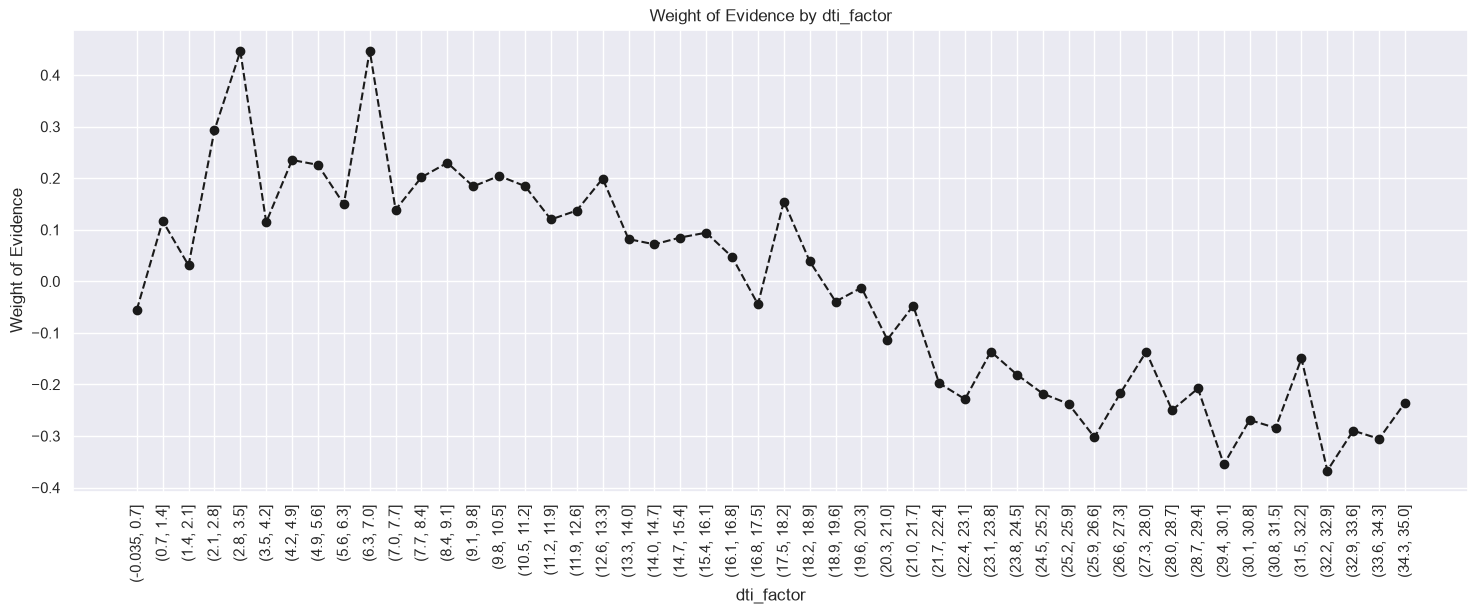

In [847]:
# Similarly to income, initial examination shows that most values are lower than 200.
# Hence, we are going to have one category for more than 35, and we are going to apply our approach to determine
# the categories of everyone with 150k or less.
df_inputs_prepr_temp = df_inputs_prepr.loc[df_inputs_prepr['dti'] <= 35, : ]

# Get the dti_factor just for those rows
df_inputs_prepr_temp['dti_factor'] = pd.cut(df_inputs_prepr_temp['dti'], 50)

column_checked = "dti_factor"

dti_factor_WoE_IV = WOE_AND_IV_updated(
    df_inputs=df_inputs_prepr_temp, # Updated new dataframe
    input_col_name=column_checked,
    df_output=df_output[df_inputs_prepr_temp.index], # Only for the rows whose index match a df_inputs_prepr['annual_inc'] < 140000
    discrete=False
)

print(dti_factor_WoE_IV)

# Plot
dti_factor_WoE_plot = plot_by_woe(
    dti_factor_WoE_IV, 90
)

In [848]:
# Categories:
df_inputs_prepr['dti:<=1.4'] = np.where((df_inputs_prepr['dti'] <= 1.4), 1, 0)
df_inputs_prepr['dti:1.4-3.5'] = np.where((df_inputs_prepr['dti'] > 1.4) & (df_inputs_prepr['dti'] <= 3.5), 1, 0)
df_inputs_prepr['dti:3.5-7.7'] = np.where((df_inputs_prepr['dti'] > 3.5) & (df_inputs_prepr['dti'] <= 7.7), 1, 0)
df_inputs_prepr['dti:7.7-10.5'] = np.where((df_inputs_prepr['dti'] > 7.7) & (df_inputs_prepr['dti'] <= 10.5), 1, 0)
df_inputs_prepr['dti:10.5-16.1'] = np.where((df_inputs_prepr['dti'] > 10.5) & (df_inputs_prepr['dti'] <= 16.1), 1, 0)
df_inputs_prepr['dti:16.1-20.3'] = np.where((df_inputs_prepr['dti'] > 16.1) & (df_inputs_prepr['dti'] <= 20.3), 1, 0)
df_inputs_prepr['dti:20.3-21.7'] = np.where((df_inputs_prepr['dti'] > 20.3) & (df_inputs_prepr['dti'] <= 21.7), 1, 0)
df_inputs_prepr['dti:21.7-22.4'] = np.where((df_inputs_prepr['dti'] > 21.7) & (df_inputs_prepr['dti'] <= 22.4), 1, 0)
df_inputs_prepr['dti:22.4-35'] = np.where((df_inputs_prepr['dti'] > 22.4) & (df_inputs_prepr['dti'] <= 35), 1, 0)
df_inputs_prepr['dti:>35'] = np.where((df_inputs_prepr['dti'] > 35), 1, 0)

C:\Users\jluyandosanchez\AppData\Local\Temp\ipykernel_23980\284476014.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['dti:<=1.4'] = np.where((df_inputs_prepr['dti'] <= 1.4), 1, 0)
C:\Users\jluyandosanchez\AppData\Local\Temp\ipykernel_23980\284476014.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['dti:1.4-3.5'] = np.where((df_inputs_prepr['dti'] > 1.4) & (df_inputs_prepr['dti'] <= 3.5), 1, 0)
C:\Users\jluyandosanchez\AppData\Local\Temp\ipykernel_23980\284476014.py:4: PerformanceWarning: D

C:\Users\jluyandosanchez\AppData\Local\Temp\ipykernel_23980\257381522.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr_temp['mths_since_last_record_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_record'], 50)
c:\Users\jluyandosanchez\Documents\ANACONDA\envs\credit_risk_course\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


   mths_since_last_record_factor  n_obs  prop_nondefaulted  prop_n_obs  \
0                 (-0.129, 2.58]    244           0.741803    0.019410   
1                   (2.58, 5.16]     36           0.888889    0.002864   
2                   (5.16, 7.74]     39           0.974359    0.003102   
3                  (7.74, 10.32]     66           0.939394    0.005250   
4                  (10.32, 12.9]     42           0.833333    0.003341   
5                  (12.9, 15.48]     69           0.884058    0.005489   
6                 (15.48, 18.06]     95           0.863158    0.007557   
7                 (18.06, 20.64]     58           0.965517    0.004614   
8                 (20.64, 23.22]    101           0.891089    0.008034   
9                  (23.22, 25.8]     94           0.946809    0.007478   
10                 (25.8, 28.38]    135           0.896296    0.010739   
11                (28.38, 30.96]    103           0.922330    0.008193   
12                (30.96, 33.54]    19

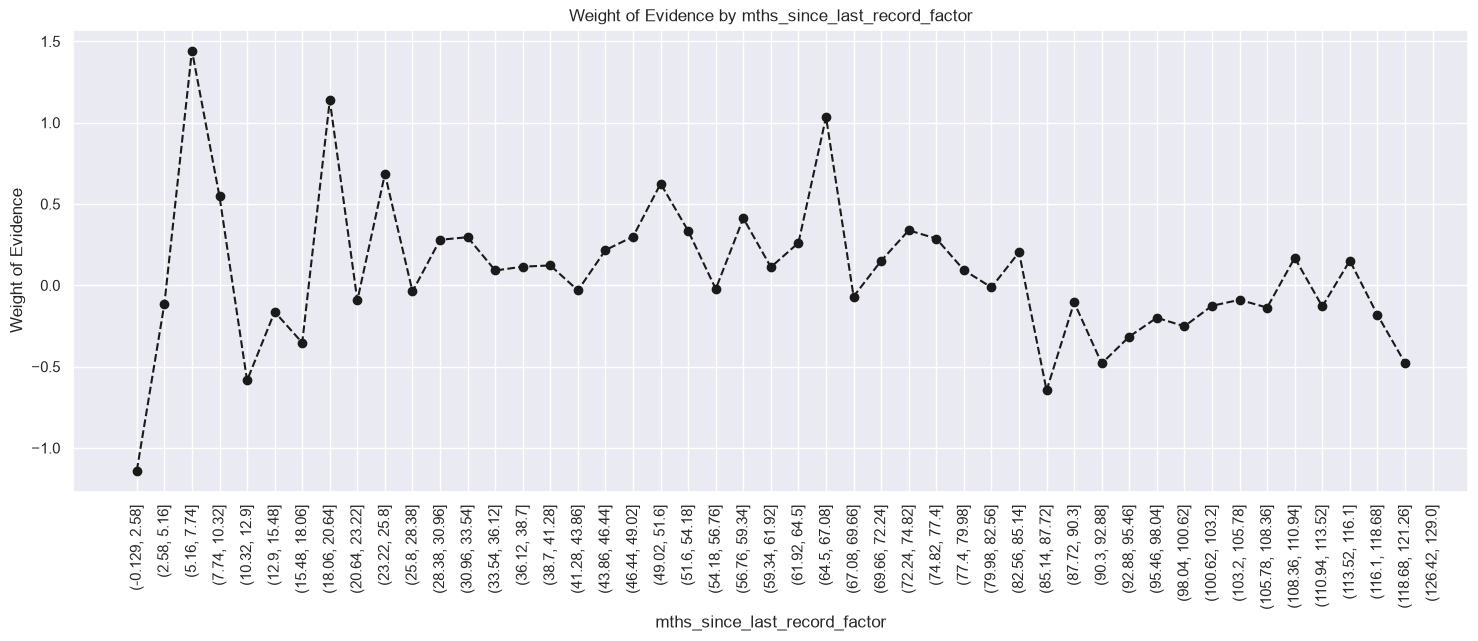

In [849]:
# mths_since_last_record

# Work only with non-empty rows
df_inputs_prepr_temp = df_inputs_prepr[pd.notnull(df_inputs_prepr.mths_since_last_record)]

# This variable is categorical, split in 50 categories
df_inputs_prepr_temp['mths_since_last_record_factor'] = pd.cut(df_inputs_prepr_temp['mths_since_last_record'], 50)

column_checked = "mths_since_last_record_factor"

mths_since_last_record_factor_WoE_IV = WOE_AND_IV_updated(
    df_inputs=df_inputs_prepr_temp, # Updated new dataframe
    input_col_name=column_checked,
    df_output=df_output[df_inputs_prepr_temp.index], # Only for the rows whose index match a df_inputs_prepr['annual_inc'] < 140000
    discrete=False
)

print(mths_since_last_record_factor_WoE_IV)

# Plot
mths_since_last_record_factor_WoE_plot = plot_by_woe(
    mths_since_last_record_factor_WoE_IV, 90
)

In [850]:
# Categories: 'Missing', '0-2', '3-20', '21-31', '32-80', '81-86', '>86'
df_inputs_prepr['mths_since_last_record:Missing'] = np.where((df_inputs_prepr['mths_since_last_record'].isnull()), 1, 0)
df_inputs_prepr['mths_since_last_record:0-2'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 0) & (df_inputs_prepr['mths_since_last_record'] <= 2), 1, 0)
df_inputs_prepr['mths_since_last_record:3-20'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 3) & (df_inputs_prepr['mths_since_last_record'] <= 20), 1, 0)
df_inputs_prepr['mths_since_last_record:21-31'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 21) & (df_inputs_prepr['mths_since_last_record'] <= 31), 1, 0)
df_inputs_prepr['mths_since_last_record:32-80'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 32) & (df_inputs_prepr['mths_since_last_record'] <= 80), 1, 0)
df_inputs_prepr['mths_since_last_record:81-86'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 81) & (df_inputs_prepr['mths_since_last_record'] <= 86), 1, 0)
df_inputs_prepr['mths_since_last_record:>86'] = np.where((df_inputs_prepr['mths_since_last_record'] > 86), 1, 0)

C:\Users\jluyandosanchez\AppData\Local\Temp\ipykernel_23980\1059239224.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_last_record:Missing'] = np.where((df_inputs_prepr['mths_since_last_record'].isnull()), 1, 0)
C:\Users\jluyandosanchez\AppData\Local\Temp\ipykernel_23980\1059239224.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_inputs_prepr['mths_since_last_record:0-2'] = np.where((df_inputs_prepr['mths_since_last_record'] >= 0) & (df_inputs_prepr['mths_since_last_record'] <= 2), 1, 0)
C:\

Let's save the train or the test dataset

In [851]:
# We can switch between test and train

# TRAIN ========================================================================================>

# # ==== INPUTS ====
# loan_data_inputs_train = df_inputs_prepr
# # Full path of the CSV file
# path_loan_data_inputs_train = os.path.join(BASE_DIR, "Import Data", "loan_data_inputs_train.csv")
# # Save DataFrame to CSV
# loan_data_inputs_train.to_csv(path_loan_data_inputs_train, index=False)
# print(f"File saved to: {path_loan_data_inputs_train}")

# # ==== OUTPUT ====
# loan_data_output_train
# # Full path of the CSV file
# path_loan_data_output_train = os.path.join(BASE_DIR, "Import Data", "loan_data_output_train.csv")
# # Save DataFrame to CSV
# loan_data_output_train.to_csv(path_loan_data_output_train, index=False)
# print(f"File saved to: {path_loan_data_output_train}")

# TEST ========================================================================================>

# ==== INPUTS ====
loan_data_inputs_test = df_inputs_prepr
# Full path of the CSV file
path_loan_data_inputs_test = os.path.join(BASE_DIR, "Import Data", "loan_data_inputs_test.csv")
# Save DataFrame to CSV
loan_data_inputs_test.to_csv(path_loan_data_inputs_test, index=False)
print(f"File saved to: {path_loan_data_inputs_test}")


# ==== OUTPUT ====
loan_data_output_test
# Full path of the CSV file
path_loan_data_output_test = os.path.join(BASE_DIR, "Import Data", "loan_data_output_test.csv")
# Save DataFrame to CSV
loan_data_output_test.to_csv(path_loan_data_output_test, index=False)
print(f"File saved to: {path_loan_data_output_test}")

File saved to: c:\Users\jluyandosanchez\Documents\Kursen\Credit Risk - Python\Import Data\loan_data_inputs_test.csv
File saved to: c:\Users\jluyandosanchez\Documents\Kursen\Credit Risk - Python\Import Data\loan_data_output_test.csv


In [852]:
# UPDATED LIST FOR OUR MODEL USAGE =======>

# DISCRETE ==>

# VARIABLES = ['grade', 'home_ownership', 'addr_state', 'verification_status', 'purpose', 'initial_list_status']

# ['grade:A', 'grade:B', 'grade:C', 'grade:D', 'grade:E', 'grade:F', 'grade:G']
# ['home_ownership:RENT_OTHER_NONE_ANY', 'home_ownership:MORTGAGE', 'home_ownership:OWN']
# ['addr_state:NE_IA_NV_FL_HI_AL', 'addr_state:NM_VA', 'addr_state:OK_TN_MO_LA_MD_NC', 'addr_state:UT_KY_AZ_NJ', 'addr_state:AR_MI_PA_OH_MN', 'addr_state:RI_MA_DE_SD_IN', 'addr_state:GA_WA_OR', 'addr_state:WI_MT', 'addr_state:IL_CT', 'addr_state:KS_SC_CO_VT_AK_MS', 'addr_state:WV_NH_WY_DC_ME_ID']
# ['verification_status:Verified', 'verification_status:Source Verified', 'Not Verified]
# ['purpose:educ__sm_b__wedd__ren_en__mov__house', 'purpose:oth__med__vacation', 'purpose:major_purch__car__home_impr']
# ['initial_list_status:f', 'initial_list_status:w']

# CONTINOUS ==>

# VARIABLES = ['term', 'emp_length', 'mths_since_issue_d', 'int_rate', 'mths_since_earliest_cr_line', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'total_acc', 'acc_now_delinq', 'total_rev_hi_lim', 'annual_inc', 'mths_since_last_delinq', 'dti', 'mths_since_last_record']

# ['term:36', 'term:60']
# ['emp_length:0', 'emp_length:1', 'emp_length:2-4', 'emp_length:5-6', 'emp_length:7-9', 'emp_length:10']
# ['mths_since_issue_d:<38', 'mths_since_issue_d:38-39', 'mths_since_issue_d:40-41', 'mths_since_issue_d:42-48', 'mths_since_issue_d:49-52', 'mths_since_issue_d:53-64', 'mths_since_issue_d:65-84', 'mths_since_issue_d:>84']
# ['int_rate:<9.548', 'int_rate:9.548-12.025', 'int_rate:12.025-15.74', 'int_rate:15.74-20.281', 'int_rate:>20.281']
# ['mths_since_earliest_cr_line:<140', 'mths_since_earliest_cr_line:141-164', 'mths_since_earliest_cr_line:165-247', 'mths_since_earliest_cr_line:248-270', 'mths_since_earliest_cr_line:271-352', 'mths_since_earliest_cr_line:>352']
# ['delinq_2yrs:0', 'delinq_2yrs:1-3', 'delinq_2yrs:>=4']
# ['inq_last_6mths:0', 'inq_last_6mths:1-2', 'inq_last_6mths:3-6', 'inq_last_6mths:>6']
# ['open_acc:0', 'open_acc:1-3', 'open_acc:4-12', 'open_acc:13-17', 'open_acc:18-22', 'open_acc:23-25', 'open_acc:26-30', 'open_acc:>=31']
# ['pub_rec:0-2', 'pub_rec:3-4', 'pub_rec:>=5']
# ['total_acc:<=27', 'total_acc:28-51', 'total_acc:>=52']
# ['acc_now_delinq:0', 'acc_now_delinq:>=1']
# ['total_rev_hi_lim:<=5K', 'total_rev_hi_lim:5K-10K', 'total_rev_hi_lim:10K-20K', 'total_rev_hi_lim:20K-30K', 'total_rev_hi_lim:30K-40K', 'total_rev_hi_lim:40K-55K', 'total_rev_hi_lim:55K-95K', 'total_rev_hi_lim:>95K']
# ['annual_inc:<20K', 'annual_inc:20K-30K', 'annual_inc:30K-40K', 'annual_inc:40K-50K', 'annual_inc:50K-60K', 'annual_inc:60K-70K', 'annual_inc:70K-80K', 'annual_inc:80K-90K', 'annual_inc:90K-100K', 'annual_inc:100K-120K', 'annual_inc:120K-140K', 'annual_inc:>140K']
# ['mths_since_last_delinq:Missing', 'mths_since_last_delinq:0-3', 'mths_since_last_delinq:4-30', 'mths_since_last_delinq:31-56', 'mths_since_last_delinq:>=57']
# ['dti:<=1.4', 'dti:1.4-3.5', 'dti:3.5-7.7', 'dti:7.7-10.5', 'dti:10.5-16.1', 'dti:16.1-20.3', 'dti:20.3-21.7', 'dti:21.7-22.4', 'dti:22.4-35', 'dti:>35']
# ['mths_since_last_record:Missing', 'mths_since_last_record:0-2', 'mths_since_last_record:3-20', 'mths_since_last_record:21-31', 'mths_since_last_record:32-80', 'mths_since_last_record:81-86', 'mths_since_last_record:>86']

# UPDATED LIST OF REFERENCE CATEGORIES ========>

# DISCRETE ==>
# 'grade:G'
# 'home_ownership:RENT_OTHER_NONE_ANY'
# 'addr_state:NE_IA_NV_FL_HI_AL'
# 'verification_status:Verified'
# 'purpose:educ__sm_b__wedd__ren_en__mov__house'
# 'initial_list_status:f'

# CONTINOUS ==>
# 'term:60'
# 'emp_length:0'
# 'mths_since_issue_d:>84'
# 'int_rate:>20.281'
# 'mths_since_earliest_cr_line:<140'
# 'delinq_2yrs:>=4'
# 'inq_last_6mths:>6'
# 'open_acc:0'
# 'pub_rec:0-2'
# 'total_acc:<=27'
# 'acc_now_delinq:0'
# 'total_rev_hi_lim:<=5K'
# 'annual_inc:<20K'
# 'mths_since_last_delinq:>=57'
# 'dti:>35'
# 'mths_since_last_record:0-2'

IN ORDER to test the model in the test set, we must have the same dummy variables as the ones in the train set